# Imports

In [25]:
import sys, os, tempfile, shutil, subprocess, json, requests, time
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import molviewspec as mvs

import pymol2
import MDAnalysis as mda
from MDAnalysis.analysis.rms import rmsd
import MDAnalysis.analysis.distances
# from openmm.app import PDBxFile
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolAlign

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sys.path.append("..")

In [3]:
from predict import \
Cif, Pocket, view_pockets

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/autogluon/common/utils/utils.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [4]:
Cif("frame_0", "bioemu_8uk6/msmclust/dihedrals/predictions/frame_0/frame_0.cif").residues

,label_comp_id,label_asym_id,pdbx_PDB_ins_code,auth_asym_id,pdbx_PDB_model_num,auth_comp_id,auth_seq_id,label_entity_id,label_seq_id
0,PRO,A,?,A,1,PRO,0,1,1
7,GLU,A,?,A,1,GLU,1,1,2
16,ARG,A,?,A,1,ARG,2,1,3
27,SER,A,?,A,1,SER,3,1,4
33,MET,A,?,A,1,MET,4,1,5
...,...,...,...,...,...,...,...,...,...
4688,ILE,A,?,A,1,ILE,575,1,576
4696,VAL,A,?,A,1,VAL,576,1,577
4703,SER,A,?,A,1,SER,577,1,578
4709,LEU,A,?,A,1,LEU,578,1,579


In [5]:
outdir = Path("dldocking")
outdir.mkdir(exist_ok=True)

## Data

In [6]:
extra_holos_featuresd = pd.read_pickle("../training_data/7.Extra_set/features.pkl")
extra_holos_featuresd

{'7gqu':     Residues                                                          \
          pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
 0       7gqu               1             A           12            A   
 1       7gqu               1             A           13            A   
 2       7gqu               1             A           14            A   
 3       7gqu               1             A           15            A   
 4       7gqu               1             A           16            A   
 ..       ...             ...           ...          ...          ...   
 414     7gqu               1             A          426            A   
 415     7gqu               1             A          427            A   
 416     7gqu               1             A          428            A   
 417     7gqu               1             A          429            A   
 418     7gqu               1             A          430            A   
 
                                   Label 

In [7]:
extra_holos_sites = {k: v for k, v in pd.read_pickle("../training_data/7.Extra_set/news_sites.pkl").items() if k in extra_holos_featuresd}
extra_holos_sites

{'7gqu': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   3420           X1L             D               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   3420                 ?        1002          X1L            A   
   
        pdbx_PDB_model_num pdbx_label_index pdbx_sifts_xref_db_name  \
   3420                  1             1002                       ?   
   
        pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_num pdbx_sifts_xref_db_res  
   3420                      ?                      ?                      ?  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            VAL             A               1           55                 ?   
   1            MET             A               1           56                 ?   
   2            ALA             A               1           57                 ?   
   3            THR             A               1         

In [8]:
apos = pd.read_pickle(f"pdb_ensemble/apos.pkl")
overlaps = pd.read_pickle(f"pdb_ensemble/predictions.pkl")
origapos = pd.read_pickle("../models/other_tools_apos/models_lenient_labelling.pkl")["model5"]

origholos = pd.read_pickle("../models/other_tools/models.pkl")["model5"]

#### 8jp0 - 8sgi

In [9]:
overlaps["8jp0"].pop("8sgi")

{'pocket': 'pocket2',
 'site_in_pocket': 0.53125,
 'pocket_in_site': 0.3695652173913043,
 'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
 0            GLU             A               1          132                 ?   
 1            THR             A               1          133                 ?   
 2            VAL             A               1          134                 ?   
 3            SER             A               1          135                 ?   
 4            LEU             A               1          137                 ?   
 5            THR             A               1          138                 ?   
 6            ALA             A               1          141                 ?   
 7            HIS             A               1          200                 ?   
 8            VAL             A               1          203                 ?   
 9            VAL             A               1          206                 ?   
 

In [10]:
seqsf = f"cofolding/seqs.pkl"

seqs = pd.read_pickle(seqsf)

In [11]:
seqsdf = pd.DataFrame({k: {k1: v1 for k1, v1 in v.items() if k1 != "site"} for k, v in seqs.items()}).T
seqsdf

,seq,seqmin,seqmax,site_seqids,ccd,smiles
7gqu,FLWPAPNEEQVTCLKMYFGHSSFKPVQWKVIHSVLEERRDNVAVMA...,12,430,"(44, 45, 46, 177, 178, 179, 180, 181, 185, 199...",X1L,CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C...
7yg5,NIVRKYAKKLIDWPPFEYMILATIIANCIVLALEQHLPEDDKTPMS...,76,1871,"(134, 135, 138, 139, 142, 278, 279, 282, 283, ...",TOR,CC1(OC2COC3(C(C2O1)OC(O3)(C)C)COS(=O)(=O)N)C
8aq6,MVFTLEDFVGDWRQTAGYNLDQVLEQGGVSSLFQNLGVSVTPIQRI...,11,181,"(11, 12, 13, 43, 45, 57, 59, 61, 83, 84, 85, 9...",NT0,c1ccc(cc1)Cc2c(ncc(n2)c3ccccc3)NC(=O)Cc4ccco4
8f4s,SSQAWQPGVAMPNLYKMQRMLLEKCDLQNYGDSATLPKGIMMNVAK...,4,301,"(68, 70, 71, 96, 98, 111, 113, 114, 115, 116, ...",XDU,c1cc(c(cc1Cl)Cl)C=Cc2cc(nc(n2)O)C(F)(F)F
8jp0,GSYYCKKGVILPIWEPQDPSFGDKIARATVYFVAMVYMFLGVSIIA...,51,937,"(82, 83, 84, 85, 87, 88, 91, 150, 153, 156, 15...",EKY,CCOc1ccc(c(c1)N)Oc2ccc(cc2)OCc3cc(ccc3F)F
8qni,QAAADRRTVEKTWKLMDKVVRLCQNPKLQLKNSPPYILDILPDTYQ...,5,387,"(104, 107, 108, 109, 111, 112, 115, 181, 182, ...",W7R,CC1CN(CCO1)Cc2ccccc2C(=O)NC3C(=O)Nc4cnccc4C(=N...
8uk6,PERSMFSEGFLGDLHKPGEEPQMYPELLEEHKKFICDKVYTRFPPE...,233,812,"(49, 50, 51, 52, 55, 280, 281, 282, 283, 284, ...",WVK,c1cc(sc1)C=CC(=O)Nc2ncccn2
8v81,RSPLEKASVVSKLFFSWTRPILRKGYRQRLELSDIYQIPSVDSADN...,1,1438,"(90, 93, 308, 309, 342, 343, 345, 346, 351, 91...",WG5,c1cc(cc(c1)N2C(=O)C(=Cc3ccc(cc3)C(=O)O)SC2=S)C...
9dnm,TRVFKKASPNGKLTVYLGKRDFVDHIDLVDPVDGVVLVDPEYLKER...,6,492,"(129, 344, 345, 346, 347, 348, 379, 380, 381, ...",ODN,CC1C2CCC3C45COC(C3(C2O)C1=O)(C(C4C(CCC5O)(C)C)O)O


In [12]:
bioemuensdir = Path("bioemu_8uk6/msmclust/dihedrals")

In [13]:
bioemuensresults = pd.read_pickle(bioemuensdir / "predictions.pkl")
bioemuensresults

{'frame_0': {'pocket': 'pocket1',
  'overlap': 0.9047619047619048,
  'merge':    label_comp_id label_asym_id pdbx_PDB_ins_code auth_asym_id  \
  0            GLY             A                 ?            A   
  1            PHE             A                 ?            A   
  2            LEU             A                 ?            A   
  3            HIS             A                 ?            A   
  4            HIS             A                 ?            A   
  5            GLY             A                 ?            A   
  6            THR             A                 ?            A   
  7            ILE             A                 ?            A   
  8            MET             A                 ?            A   
  9            LYS             A                 ?            A   
  10           ILE             A                 ?            A   
  11           TRP             A                 ?            A   
  12           ARG             A                 ?   

# Consensus residues

In [14]:
guide_resf = outdir / "guide_res.pkl"

if guide_resf.exists():
    guide_res = pd.read_pickle(guide_resf)
else:
    guide_res = {}

## Calculation

## Results

In [15]:
guide_res_df = pd.DataFrame(guide_res).T
guide_res_df

,seqids,all_seqids,mean_overlap,top_3_overlap,top_3_overlaps,overlaps,topres
7gqu,"(47, 204, 323)","[47, 204, 323]",0.264212,1,label_comp_id label_asym_id label_entity_id ...,"[0.14864864864864866, 0.06896551724137931, 0.4...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
7yg5,"(710, 1710, 1742)","[399, 401, 403, 404, 405, 407, 408, 409, 451, ...",0.0,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.0, 0.0, 0.0]",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_...
8aq6,"(60, 79, 94)","[40, 42, 60, 79, 94]",0.114211,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.07142857142857142, 0.0, 0.3333333333333333,...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8f4s,"(130, 132, 149)","[70, 71, 98, 130, 132, 133, 149]",0.246201,1,label_comp_id label_asym_id label_entity_id ...,"[0.5263157894736842, 0.4230769230769231, 0.0, ...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8qni,"(183, 199, 203)","[183, 199, 203]",0.427736,1,label_comp_id label_asym_id label_entity_id ...,"[0.5517241379310345, 0.6086956521739131, 0.043...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8v81,"(261, 264, 265)","[261, 264, 265]",0.116819,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.13978494623655913, 0.0, 0.0, 0.0, 0.0, 0.0,...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
9dnm,"(121, 122, 386)","[121, 122, 164, 386, 394]",0.247056,0,"Empty DataFrame Columns: [label_comp_id, label...","[0.01694915254237288, 0.0, 0.4, 0.6, 0.0, 0.88...",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_nu...
8jp0,"(54, 82, 826)","[50, 54, 82, 83, 84, 87, 88, 90, 91, 148, 150,...",0.422506,1,label_comp_id label_asym_id label_entity_id ...,"[0.18888888888888888, 0.5625, 0.5161290322580645]",pdbx_sifts_xref_db_acc pdbx_sifts_xref_db_n...
8uk6,"(52, 58, 283)","[52, 55, 58, 246, 273, 283]",0.480159,2,label_comp_id label_asym_id label_entity_id ...,"[0.9047619047619048, 0.6190476190476191, 0.523...",label_seq_id 0 52 1 283 4...


In [27]:
all_rmsds = {}

# DiffDock

In [28]:
diffdockdir = outdir / "diffdock"
diffdockdir.mkdir(exist_ok=True)

## Translation temperature tests

### holo

### apos

## Default

In [77]:
dockings = []

for holo, holod in overlaps.items():
    # if holo in ("7yg5", "8v81"):
    #     continue
        
    path = diffdockdir / holo
    path.mkdir(exist_ok = True)

    smi = seqs[holo]["smiles"]

    if not (path / holo).exists():
        dockings.append({
            "complex_name": f"{holo}/{holo}",
            "protein_path": f"../training_data/7.Extra_set/cifs/{holo}.cif",
            "ligand_description": smi,
            "protein_sequence": None
        })

    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    if not (path / refapo).exists():
        dockings.append({
            "complex_name": f"{holo}/{refapo}",
            "protein_path": f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif",
            "ligand_description": smi,
            "protein_sequence": None
        })

    for apo in holod.keys():
        if not (path / apo).exists():
            dockings.append({
                "complex_name": f"{holo}/{apo}",
                "protein_path": f"pdb_ensemble/predictions/{apo}/{apo}.cif",
                "ligand_description": smi,
                "protein_sequence": None
            })


holo = "8uk6"
path = diffdockdir / holo
path.mkdir(exist_ok = True)

smi = seqs[holo]["smiles"]

if not (path / holo).exists():
    dockings.append({
        "complex_name": f"{holo}/{holo}",
        "protein_path": f"../training_data/7.Extra_set/cifs/{holo}.cif",
        "ligand_description": smi,
        "protein_sequence": None
    })

for apo in bioemuensresults:
    if not (path / apo).exists():
        dockings.append({
            "complex_name": f"{holo}/{apo}",
            "protein_path": str(bioemuensdir / f"predictions/{apo}/{apo}.cif"),
            "ligand_description": smi,
            "protein_sequence": None
        })

 

dockings

[{'complex_name': '7gqu/7gqu',
  'protein_path': '../training_data/7.Extra_set/cifs/7gqu.cif',
  'ligand_description': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F',
  'protein_sequence': None},
 {'complex_name': '7gqu/6yhr',
  'protein_path': '../training_data/8.Apos/Extra_set/cifs/6yhr.cif',
  'ligand_description': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F',
  'protein_sequence': None},
 {'complex_name': '7gqu/7gqt',
  'protein_path': 'pdb_ensemble/predictions/7gqt/7gqt.cif',
  'ligand_description': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F',
  'protein_sequence': None},
 {'complex_name': '7gqu/8yle',
  'protein_path': 'pdb_ensemble/predictions/8yle/8yle.cif',
  'ligand_description': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F',
  'protein_sequence': None},
 {'complex_name': '7gqu/8pfp',
  'protein_path': 'pdb_ensemble/predictions/8pfp/8pfp.cif',
  'ligand_description': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F',
 

In [78]:
dockingsf = diffdockdir / "dockings.csv"
pd.DataFrame(dockings).to_csv(dockingsf, index=False)

In [80]:
subprocess.run(f"""
/data/fnerin/ensembles/diffdock_env/bin/python dldocking/DiffDock/inference.py \
--config {diffdockdir / "default_inference_args.yaml"} \
--protein_ligand_csv {dockingsf} \
-l DEBUG \
--out_dir {diffdockdir} \
--save_visualisation \
--samples_per_complex 5 \
--model_dir /data/fnerin/ensembles/diffdock_workdir/v1.1/score_model \
--confidence_model_dir /data/fnerin/ensembles/diffdock_workdir/v1.1/confidence_model \
--confidence_ckpt best_model_epoch75.pt
""",
    # [--ckpt CKPT]
    # [--batch_size BATCH_SIZE] [--no_final_step_noise]
    # [--inference_steps INFERENCE_STEPS]
    # [--actual_steps ACTUAL_STEPS] [--old_score_model]
    # [--old_confidence_model]
    # [--initial_noise_std_proportion INITIAL_NOISE_STD_PROPORTION]
    # [--choose_residue] [--temp_sampling_tr TEMP_SAMPLING_TR]
    # [--temp_psi_tr TEMP_PSI_TR]
    # [--temp_sigma_data_tr TEMP_SIGMA_DATA_TR]
    # [--temp_sampling_rot TEMP_SAMPLING_ROT]
    # [--temp_psi_rot TEMP_PSI_ROT]
    # [--temp_sigma_data_rot TEMP_SIGMA_DATA_ROT]
    # [--temp_sampling_tor TEMP_SAMPLING_TOR]
    # [--temp_psi_tor TEMP_PSI_TOR]
    # [--temp_sigma_data_tor TEMP_SIGMA_DATA_TOR]
    # [--gnina_minimize] [--gnina_path GNINA_PATH]
    # [--gnina_log_file GNINA_LOG_FILE] [--gnina_full_dock]
    # [--gnina_autobox_add GNINA_AUTOBOX_ADD]
    # [--gnina_poses_to_optimize GNINA_POSES_TO_OPTIMIZE]
    # """,
    shell=True, check=True
)

/data/fnerin/ensembles/diffdock_env/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
[2025-Sep-26 18:24:53 EEST] [inference.py:153] INFO - DiffDock will run on cuda
[2025-Sep-26 18:25:07 EEST] [inference.py:184] INFO - Confidence model uses different type of graphs than the score model. Loading (or creating if not existing) the data for the confidence model now.
[2025-Sep-26 18:25:10 EEST] [inference.py:223] INFO - Size of test dataset: 159
0it [00:00, ?it/s]/home/fnerin/Desktop/AlloPockets/ensembles/dldocking/DiffDock/datasets/parse_chi.py:91: RuntimeWarning: invalid value encountered in cast
  Y = indices.astype(int)


Generating ESM language model embeddings
Processing 1 of 22 batches (13 sequences)
Processing 2 of 22 batches (13 sequences)
Processing 3 of 22 batches (13 sequences)
Processing 4 of 22 batches (13 sequences)
Processing 5 of 22 batches (13 sequences)
Processing 6 of 22 batches (13 sequences)
Processing 7 of 22 batches (11 sequences)
Processing 8 of 22 batches (10 sequences)
Processing 9 of 22 batches (7 sequences)
Processing 10 of 22 batches (7 sequences)
Processing 11 of 22 batches (7 sequences)
Processing 12 of 22 batches (7 sequences)
Processing 13 of 22 batches (6 sequences)
Processing 14 of 22 batches (4 sequences)
Processing 15 of 22 batches (3 sequences)
Processing 16 of 22 batches (3 sequences)
Processing 17 of 22 batches (3 sequences)
Processing 18 of 22 batches (3 sequences)
Processing 19 of 22 batches (3 sequences)
Processing 20 of 22 batches (3 sequences)
Processing 21 of 22 batches (3 sequences)
Processing 22 of 22 batches (1 sequences)


6it [00:58,  9.06s/it][2025-Sep-26 18:26:10 EEST] [inference.py:227] WARNING - The test dataset did not contain 7yg5/7yg5 for CC1(OC2COC3(C(C2O1)OC(O3)(C)C)COS(=O)(=O)N)C and ../training_data/7.Extra_set/cifs/7yg5.cif. We are skipping this complex.
7it [00:59,  6.21s/it][2025-Sep-26 18:26:10 EEST] [inference.py:227] WARNING - The test dataset did not contain 7yg5/7xlq for CC1(OC2COC3(C(C2O1)OC(O3)(C)C)COS(=O)(=O)N)C and ../training_data/8.Apos/Extra_set/cifs/7xlq.cif. We are skipping this complex.
9it [01:10,  6.42s/it][2025-Sep-26 18:26:21 EEST] [inference.py:227] WARNING - The test dataset did not contain 7yg5/8epl for CC1(OC2COC3(C(C2O1)OC(O3)(C)C)COS(=O)(=O)N)C and pdb_ensemble/predictions/8epl/8epl.cif. We are skipping this complex.
19it [01:51,  4.48s/it][2025-Sep-26 18:27:03 EEST] [sampling.py:123] WARNING - Complex ['8f4s/8f4s'] Batch 1 Inference Iteration 2: 1 / 5 samples failed
[2025-Sep-26 18:27:03 EEST] [sampling.py:123] WARNING - Complex ['8f4s/8f4s'] Batch 1 Inference Ite

Skipping 7yg5/7yg5 because of the error:
Sizes of tensors must match except in dimension 1. Expected size 1319 but got size 1022 for tensor number 1 in the list.
Skipping 7yg5/7xlq because of the error:
Sizes of tensors must match except in dimension 1. Expected size 1319 but got size 1022 for tensor number 1 in the list.
Skipping 7yg5/8epl because of the error:
Sizes of tensors must match except in dimension 1. Expected size 1274 but got size 1022 for tensor number 1 in the list.
Skipping 8v81/8v81 because of the error:
Sizes of tensors must match except in dimension 1. Expected size 1132 but got size 1022 for tensor number 1 in the list.
Skipping 8v81/5uak because of the error:
Sizes of tensors must match except in dimension 1. Expected size 1139 but got size 1022 for tensor number 1 in the list.
Skipping 8v81/6o1v because of the error:
Sizes of tensors must match except in dimension 1. Expected size 1166 but got size 1022 for tensor number 1 in the list.
Skipping 8v81/9dw8 because o

CompletedProcess(args='\n/data/fnerin/ensembles/diffdock_env/bin/python dldocking/DiffDock/inference.py --config dldocking/diffdock/default_inference_args.yaml --protein_ligand_csv dldocking/diffdock/dockings.csv -l DEBUG --out_dir dldocking/diffdock --save_visualisation --samples_per_complex 5 --model_dir /data/fnerin/ensembles/diffdock_workdir/v1.1/score_model --confidence_model_dir /data/fnerin/ensembles/diffdock_workdir/v1.1/confidence_model --confidence_ckpt best_model_epoch75.pt\n', returncode=0)

In [81]:
subprocess.run(
    f"""rm .so3_cdf_vals4.npy  .so3_exp_score_norms4.npy  .so3_omegas_array4.npy  .so3_score_norms4.npy .p.npy .score.npy""",
    shell=True, check=True
)

CompletedProcess(args='rm .so3_cdf_vals4.npy  .so3_exp_score_norms4.npy  .so3_omegas_array4.npy  .so3_score_norms4.npy .p.npy .score.npy', returncode=0)

## Results

In [29]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    # if holo in ("7yg5", "8v81"):
    #     continue

    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        if not (diffdockdir / holo / apo / "rank1.sdf").exists(): ###########################################
            continue

        with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
            with pymol2.PyMOL() as pymol:
                cmd = pymol.cmd
                cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                
                if apo != holo:
                    if holo == "8uk6":
                        apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                    else:
                        apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                    cmd.load(apof, "apo")
                    rmsd, aligned, *_ = cmd.align(f'holo and segid {extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()}', 'apo')
                               
                cmd.select("ligand", f'holo and segid {extra_holos_sites[holo][0]["mod"].label_asym_id.unique().item()}')
                cmd.save(f.name, "ligand")

                #############################################################################################
                for i in range(1,5+1):
                    cmd.load(next((diffdockdir / holo / apo).glob(f"rank{i}_*.sdf")), f"docked_ligand_{i}")
                    cmd.save(diffdockdir / holo / apo / f"result_{i}.pdb", (f"ligand or docked_ligand_{i}") + (" or apo" if apo != holo else " or holo"))
                
            ref = mda.Universe(f.name)
            refatoms = mda.AtomGroup(
                sorted(
                    ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
        
        for i in range(1,5+1):
            lig = mda.Universe(diffdockdir / holo / apo / f"rank{i}_reverseprocess.pdb")
            lig.trajectory[-1]
            ligatoms = mda.AtomGroup(
                sorted(
                    lig.select_atoms("not type H"), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
            
            rmsds.append({
                "holo": holo,
                "apo": apo,
                "sample": i,
                "dist": mda.analysis.distances.distance_array(
                    refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                ).item(),
                "rmsd": rdMolAlign.CalcRMS(
                            refatoms.convert_to("RDKIT", NoImplicit=False), 
                            ligatoms.convert_to("RDKIT", NoImplicit=False)
                        )
                        # mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
            })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


,holo,apo,sample,dist,rmsd
0,7gqu,7gqu,1,26.980875,27.706482
1,7gqu,7gqu,2,18.408502,18.972822
2,7gqu,7gqu,3,26.746817,27.393894
3,7gqu,7gqu,4,20.506082,21.859948
4,7gqu,7gqu,5,17.244518,18.994596
...,...,...,...,...,...
680,8uk6,frame_23,1,22.017662,23.063284
681,8uk6,frame_23,2,20.680047,21.677414
682,8uk6,frame_23,3,22.345395,23.556946
683,8uk6,frame_23,4,18.682291,19.774512


In [19]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,sample,dist,rmsd
489,9dnm,8hst,5,3.989273e+07,3.989273e+07
84,8f4s,8f4s,5,1.496922e+03,1.496929e+03
603,8uk6,frame_7,4,5.093145e+02,5.093476e+02
597,8uk6,frame_6,3,1.113110e+02,1.114017e+02
529,9dnm,8i0q,5,6.952804e+01,6.969806e+01
349,8f4s,8rvb,5,5.110227e+01,5.153598e+01
471,9dnm,9cx9,2,4.999904e+01,5.015371e+01
30,7yg5,8epm,1,4.298215e+01,4.316073e+01
31,7yg5,8epm,2,4.253715e+01,4.274071e+01
496,9dnm,6kl7,2,4.240484e+01,4.260142e+01


In [20]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,sample,dist,rmsd
489,9dnm,8hst,5,3.989273e+07,3.989273e+07
84,8f4s,8f4s,5,1.496922e+03,1.496929e+03
603,8uk6,frame_7,4,5.093145e+02,5.093476e+02
597,8uk6,frame_6,3,1.113110e+02,1.114017e+02
529,9dnm,8i0q,5,6.952804e+01,6.969806e+01
349,8f4s,8rvb,5,5.110227e+01,5.153598e+01
471,9dnm,9cx9,2,4.999904e+01,5.015371e+01
30,7yg5,8epm,1,4.298215e+01,4.316073e+01
31,7yg5,8epm,2,4.253715e+01,4.274071e+01
496,9dnm,6kl7,2,4.240484e+01,4.260142e+01


In [21]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[-40:]

,holo,apo,sample,dist,rmsd
495,9dnm,6kl7,1,12.414258,13.196699
501,9dnm,8j8z,2,12.491440,13.094987
504,9dnm,8j8z,5,12.186884,12.782499
490,9dnm,8ja3,1,12.239279,12.742298
528,9dnm,8i0q,4,12.024850,12.700921
503,9dnm,8j8z,4,11.771034,12.390141
537,9dnm,8go8,3,11.398842,12.361830
511,9dnm,9cx3,2,11.659428,12.193207
510,9dnm,9cx3,1,11.659917,12.192371
512,9dnm,9cx3,3,11.617967,12.162222


In [30]:
all_rmsds["diffdock"] = rmsds_df

#### Plot

In [126]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    ).loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

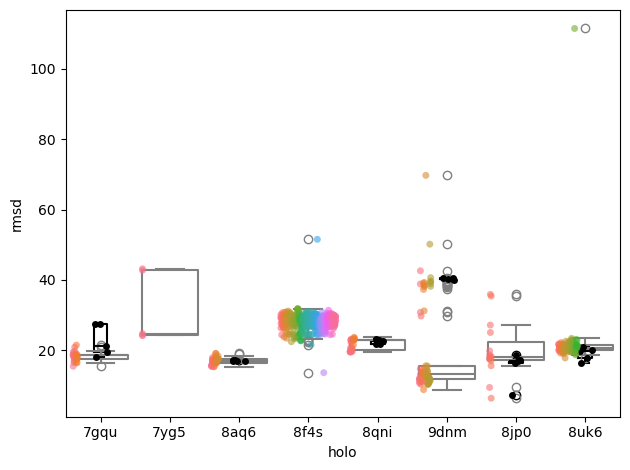

In [127]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [128]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 50]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 50]

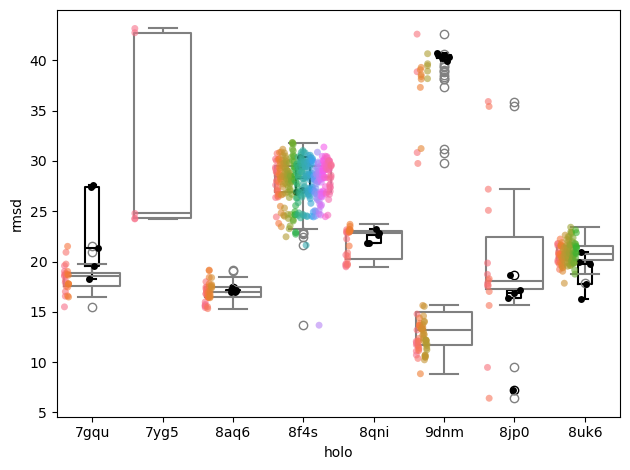

In [129]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

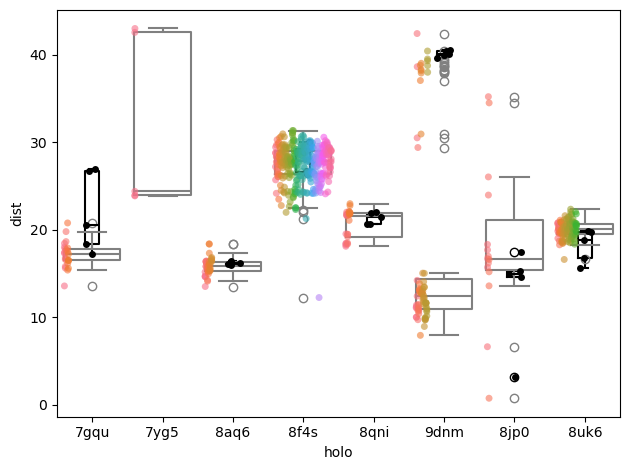

In [130]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

# DiffDock-Pocket

In [31]:
diffdockpdir = outdir / "diffdock-pocket"
diffdockpdir.mkdir(exist_ok=True)

In [50]:
dockings = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": None}
).items():
    if holo in ("7yg5", "8v81"): # There are no good guide residues or pockets for these
        continue
        
    path = diffdockpdir / holo
    path.mkdir(exist_ok = True)

    guideres = guide_res[holo]["topres"] # label_seq_id will prob be wrong for 8uk6 apos

    smi = seqs[holo]["smiles"]
    mol = Chem.AddHs(Chem.MolFromSmiles(smi))
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    conf = mol.GetConformer()
    
    files = {
        holo: {
            "ciff": f"../training_data/7.Extra_set/cifs/{holo}.cif",
            "pfile": f"../training_data/7.Extra_set/pockets/{holo}/{holo}_out/{holo}_out.cif",
            "pocket": pd.DataFrame(origholos["results"][holo]).T.sort_values("prob", ascending=False).iloc[0].name.replace('pocket', '')
        }
    }
    
    if holo == "8uk6":
        files.update({
            frame: {
                "ciff": bioemuensdir / f"predictions/{frame}/{frame}.cif",
                "pfile": bioemuensdir / f"predictions/{frame}/{frame}/{frame}_out/{frame}_out.cif",
                "pocket": framed['pocket'].replace('pocket', '')
            }
            for frame, framed in bioemuensresults.items()
        })
    else:
        refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        files[refapo] = {
            "ciff": f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif",
            "pfile": f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/{refapo}_out.cif",
            "pocket": pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False).iloc[0].name.replace('pocket', '')
        }
        files.update({
            apo: {
                "ciff": f"pdb_ensemble/predictions/{apo}/{apo}.cif",
                "pfile": f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/{apo}_out.cif",
                "pocket": apod['pocket'].replace('pocket', '')
            }
            for apo, apod in holod.items()
        })
    
    for apo, apod in files.items():
        ciff = apod["ciff"]
        cif = Cif(apo, ciff)
        pdbf = path / f"{apo}.pdb"
        
        with pymol2.PyMOL() as pymol:
            cmd = pymol.cmd
            cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"

            cmd.load(ciff, "prot")
            cmd.save(pdbf, "prot")
            
            cmd.load(apod["pfile"], "pockets")
            # cmd.load(f"../training_data/7.Extra_set/pockets/7gqu/7gqu_out/7gqu_out.cif", "prot")
            save = True
            for label, sel in [
                ("pocket", f"resn STP and resi {apod['pocket']}"), 
                (
                    "guide",
                     " or ".join(
                        f"{res['label_asym_id']}/{res['auth_asym_id']}/{res['auth_comp_id']}`{res['auth_seq_id']}{res['pdbx_PDB_ins_code'].replace('?', '')}/*"
                        for i, res in cif.residues.merge(guideres).iterrows()
                    )
                )
            ]:
                if (path / f"{apo}_{label}").exists():
                    save = False
                    continue
                cmd.pseudoatom(f"{label}_cog", selection=sel)
                cog = cmd.get_model(f"{label}_cog").atom[0].coord

                coords = np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])
                shift = np.array(cog) - coords.mean(axis=0)
                for i in range(mol.GetNumAtoms()):
                    p = conf.GetAtomPosition(i)
                    conf.SetAtomPosition(i, (p.x+shift[0], p.y+shift[1], p.z+shift[2]))
                    
                sdff = path / f"{apo}_{label}.sdf"
                Chem.SDWriter(sdff).write(mol)

                dockings.append(dict(
                    **{
                        "complex_name": f"{holo}_{apo}_{label}",
                        "experimental_protein": pdbf,
                        "ligand": str(sdff)
                    },
                    **{col: None for col in ["pocket_center_x", "pocket_center_y", "pocket_center_z", "flexible_sidechains"]}
                ))

dockings

dict_keys(['8uk6'])
8uk6


[{'complex_name': '8uk6_8uk6_pocket',
  'experimental_protein': PosixPath('dldocking/diffdock-pocket/8uk6/8uk6.pdb'),
  'ligand': 'dldocking/diffdock-pocket/8uk6/8uk6_pocket.sdf',
  'pocket_center_x': None,
  'pocket_center_y': None,
  'pocket_center_z': None,
  'flexible_sidechains': None},
 {'complex_name': '8uk6_8uk6_guide',
  'experimental_protein': PosixPath('dldocking/diffdock-pocket/8uk6/8uk6.pdb'),
  'ligand': 'dldocking/diffdock-pocket/8uk6/8uk6_guide.sdf',
  'pocket_center_x': None,
  'pocket_center_y': None,
  'pocket_center_z': None,
  'flexible_sidechains': None},
 {'complex_name': '8uk6_frame_0_pocket',
  'experimental_protein': PosixPath('dldocking/diffdock-pocket/8uk6/frame_0.pdb'),
  'ligand': 'dldocking/diffdock-pocket/8uk6/frame_0_pocket.sdf',
  'pocket_center_x': None,
  'pocket_center_y': None,
  'pocket_center_z': None,
  'flexible_sidechains': None},
 {'complex_name': '8uk6_frame_0_guide',
  'experimental_protein': PosixPath('dldocking/diffdock-pocket/8uk6/frame_

In [51]:
dockingsf = diffdockpdir / "dockings.csv"
pd.DataFrame(dockings).to_csv(dockingsf, index=False)

In [53]:
subprocess.run(f"""
/data/fnerin/ensembles/diffdock-pocket_env/bin/python dldocking/DiffDock-Pocket/inference.py \
--config {diffdockpdir / 'config.yaml'} \
--protein_ligand_csv {dockingsf} \
--out_dir {diffdockpdir} \
--save_visualisation \
--samples_per_complex 5 \
--keep_local_structures
""",
    shell=True, check=True
)

/data/fnerin/ensembles/diffdock-pocket_env/lib/python3.9/site-packages/pdbfixer/pdbfixer.py:58: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
50it [00:00, 7678.50it/s]


DiffDock-Pocket default device: cuda
Data Preprocessing. Reading molecules and generating local structures with RDKit


[2025-09-25 22:50:29,936] {process_mols.py:930} WARNING - Number of PDBConstructionWarnings in get_sequences: 50


Generating graphs for ligands and proteins
Computing ESM embeddings for 50 proteins...
Processing 1 of 8 batches (7 sequences)
Processing 2 of 8 batches (7 sequences)
Processing 3 of 8 batches (7 sequences)
Processing 4 of 8 batches (7 sequences)
Processing 5 of 8 batches (7 sequences)
Processing 6 of 8 batches (7 sequences)
Processing 7 of 8 batches (7 sequences)
Processing 8 of 8 batches (1 sequences)


Loading complexes: 100%|██████████| 50/50 [00:08<00:00,  6.09it/s]
0it [00:00, ?it/s]

...

50it [00:00, 55.83it/s]
/data/fnerin/ensembles/diffdock-pocket_env/lib/python3.9/site-packages/torch/jit/_check.py:181: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn("The TorchScript type system doesn't support "
/data/fnerin/ensembles/diffdock-pocket_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
Docking inference:   0%|          | 0/50 [00:00<?, ?it/s, Row 0, complex 8uk6_8uk6_pocket]

Number of complexes:  50 of which 0 failed
radius protein: mean 20.639965057373047, std 1.8100727796554565, min 17.388151168823242, max 26.10236358642578, sum 1031.998291015625
radius molecule: mean 5.118275165557861, std 2.5755298338481225e-05, min 5.118221759796143, max 5.118316173553467, sum 255.91375732421875
distance protein-mol: mean 2.3458008766174316, std 1.107654333114624, min 0.937171220779419, max 6.891879081726074, sum 117.2900390625
rmsd matching: mean 0.0, std 0.0, min 0, max 0, sum 0
sidechain conformer match rotations: mean 0.0, std 0.0, min 0, max 0, sum 0
sidechain_conformer_match_improvements: mean 0.0, std 0.0, min 0, max 0, sum 0
rec_lig_steric_clashes: mean 0.0, std 0.0, min 0, max 0, sum 0, percentage: 0.0
rec_sc_lig_steric_clashes: mean 24.36, std 9.961445678213579, min 6, max 49, sum 1218, percentage: 100.0
rec_sc_rec_rest_steric_clashes: mean 0.6437766197049392, std 0.08589857692683298, min 0.4375, max 0.875, sum 32.18883098524696, percentage: 100.0
rec_sc_rec

Docking inference: 100%|██████████| 50/50 [11:09<00:00, 13.39s/it, Row 49, complex 8uk6_frame_23_guide] 


Completed 50 / 50 inferences
Results are in dldocking/diffdock-pocket


CompletedProcess(args='\n/data/fnerin/ensembles/diffdock-pocket_env/bin/python dldocking/DiffDock-Pocket/inference.py --config dldocking/diffdock-pocket/config.yaml --protein_ligand_csv dldocking/diffdock-pocket/dockings.csv --out_dir dldocking/diffdock-pocket --save_visualisation --samples_per_complex 5 --keep_local_structures\n', returncode=0)

In [56]:
for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    if holo in ("7yg5", "8v81"):
        continue
        
    path = diffdockpdir / holo
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    
    for apo in [holo, refapo] + list(holod.keys()):
        for guide in ("pocket",  "guide"):
            newpath = path / f"{apo}_{guide}"
            try:
                (
                    next(diffdockpdir.glob(f"*{apo}_{guide}.sdf"))
                    .rename(newpath)
                )
            except StopIteration:
                if not newpath.exists():
                    print(apo, guide)

7snr pocket
7snr guide
6w61 pocket
6w61 guide
3zni pocket
3zni guide


In [57]:
subprocess.run(
    f"""rm .so3_cdf_vals2.npy  .so3_exp_score_norms2.npy  .so3_omegas_array2.npy  .so3_score_norms2.npy .p.npy .score.npy""",
    shell=True, check=True
)

CompletedProcess(args='rm .so3_cdf_vals2.npy  .so3_exp_score_norms2.npy  .so3_omegas_array2.npy  .so3_score_norms2.npy .p.npy .score.npy', returncode=0)

## Results

In [32]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    if holo in ("7yg5", "8v81"):
        continue

    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        
        with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
            with pymol2.PyMOL() as pymol:
                cmd = pymol.cmd
                cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                
                if apo != holo:
                    if holo == "8uk6":
                        apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                    else:
                        apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                    cmd.load(apof, "apo")
                    rmsd, aligned, *_ = cmd.align(f'holo and segid {extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()}', 'apo')
                    
                               
                cmd.select("ligand", f'holo and segid {extra_holos_sites[holo][0]["mod"].label_asym_id.unique().item()}')
                cmd.save(f.name, "ligand")

            ref = mda.Universe(f.name)
            refatoms = mda.AtomGroup(
                sorted(
                    ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
        
        for guide in ("guide", "pocket"):
            if not (diffdockpdir / holo / f"{apo}_{guide}" / "rank1.sdf").exists(): ###########################################
                continue
            for i in range(1,5+1):
                lig = mda.Universe(diffdockpdir / holo / f"{apo}_{guide}" / f"rank{i}_reverseprocess.pdb")
                lig.trajectory[-1]
                ligatoms = mda.AtomGroup(
                    sorted( 
                        lig.select_atoms("not type H"), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
                
                rmsds.append({
                    "holo": holo,
                    "apo": apo,
                    "guide": guide,
                    "sample": i,
                    "dist": mda.analysis.distances.distance_array(refatoms.center_of_geometry(), ligatoms.center_of_geometry()).item(),
                    "rmsd": rdMolAlign.CalcRMS(
                                refatoms.convert_to("RDKIT", NoImplicit=False), 
                                ligatoms.convert_to("RDKIT", NoImplicit=False)
                            )
                            # mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
                })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


,holo,apo,guide,sample,dist,rmsd
0,7gqu,7gqu,guide,1,11.003734,12.225400
1,7gqu,7gqu,guide,2,11.643270,13.052231
2,7gqu,7gqu,guide,3,11.806760,13.308842
3,7gqu,7gqu,guide,4,11.864870,12.962796
4,7gqu,7gqu,guide,5,11.583434,13.020399
...,...,...,...,...,...,...
1325,8uk6,frame_23,pocket,1,14.358107,14.448179
1326,8uk6,frame_23,pocket,2,14.731420,14.851036
1327,8uk6,frame_23,pocket,3,15.133952,16.942393
1328,8uk6,frame_23,pocket,4,16.186872,17.008708


In [ ]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

In [33]:
all_rmsds["diffdock-pocket"] = rmsds_df

#### Plot

In [69]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]

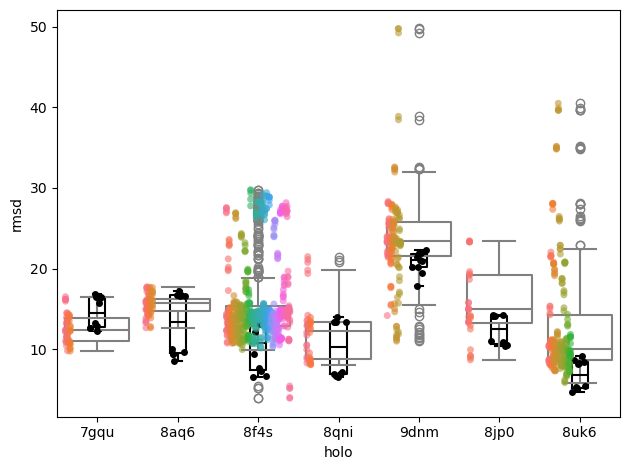

In [70]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2 #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray"
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o" # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o"
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [71]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 20]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 20]
all_holos = rmsds_df2["holo"].unique()

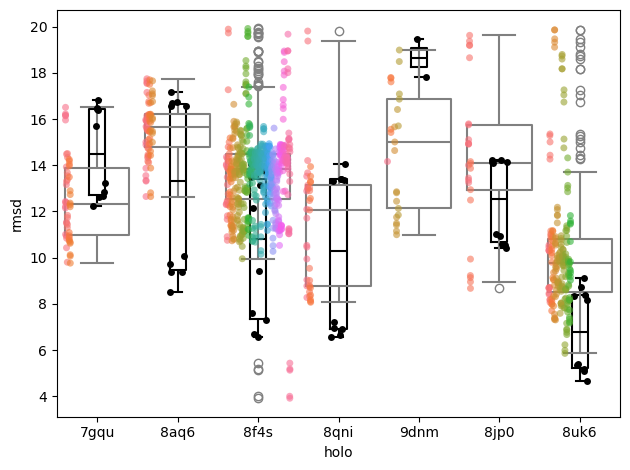

In [72]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

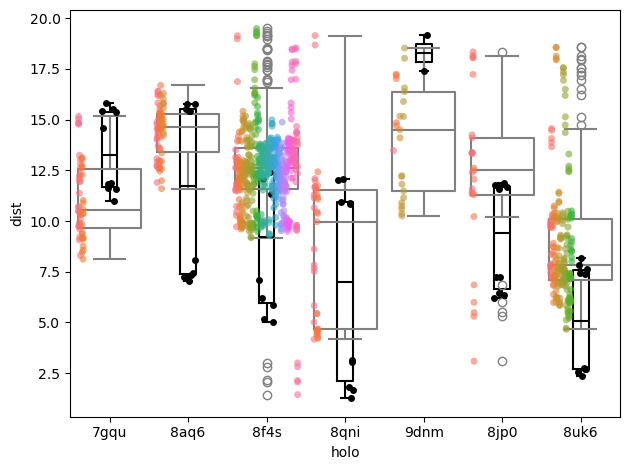

In [73]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [74]:
rmsds_df.sort_values("rmsd")

,holo,apo,guide,sample,dist,rmsd
739,8f4s,9q8h,pocket,5,1.444569,3.914952
738,8f4s,9q8h,pocket,4,2.069871,4.000504
1087,8uk6,8uk6,pocket,3,2.360745,4.648791
1088,8uk6,8uk6,pocket,4,2.702480,5.075806
735,8f4s,9q8h,pocket,1,2.143361,5.128061
...,...,...,...,...,...,...
1279,8uk6,frame_18,pocket,5,39.537712,39.905797
1278,8uk6,frame_18,pocket,4,40.111947,40.495379
989,9dnm,9cx3,pocket,5,49.052304,49.217268
986,9dnm,9cx3,pocket,2,49.542674,49.732747


In [75]:
rmsds_df.query("apo == '9cx3'")

,holo,apo,guide,sample,dist,rmsd
980,9dnm,9cx3,guide,1,19.826640,20.179612
981,9dnm,9cx3,guide,2,21.088433,21.412725
982,9dnm,9cx3,guide,3,15.153182,15.701865
983,9dnm,9cx3,guide,4,11.484373,12.130724
984,9dnm,9cx3,guide,5,11.154496,11.845516
985,9dnm,9cx3,pocket,1,38.250795,38.450323
986,9dnm,9cx3,pocket,2,49.542674,49.732747
987,9dnm,9cx3,pocket,3,38.643687,38.877157
988,9dnm,9cx3,pocket,4,49.605288,49.769865
989,9dnm,9cx3,pocket,5,49.052304,49.217268


# FlowDock

In [111]:
flowdockdir = outdir / "flowdock"
flowdockdir.mkdir(exist_ok=True)

In [113]:
dockings = []

for holo, holod in overlaps.items():
    # if holo in ("7yg5", "8v81"):
    #     continue
        
    path = flowdockdir / f"input_{holo}"
    path.mkdir(exist_ok = True)

    smi = seqs[holo]["smiles"]

    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    pdbf = path / f"{refapo}_prot.pdb"
    with pymol2.PyMOL() as pymol:
        pymol.cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
        pymol.cmd.load(f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif", "prot")
        pymol.cmd.save(pdbf, "prot")

    dockings.append({
        "id": f"{holo}_{refapo}",
        "input_receptor": pdbf,
        "input_template": pdbf,
        "input_ligand": smi,
    })

    for apo, apod in holod.items():
        pdbf = path / f"{apo}_prot.pdb"
        with pymol2.PyMOL() as pymol:
            pymol.cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
            pymol.cmd.load(f"pdb_ensemble/predictions/{apo}/{apo}.cif", "prot")
            pymol.cmd.save(pdbf, "prot")
        dockings.append({
            "id": f"{holo}_{apo}",
            "input_receptor": pdbf,
            "input_template": pdbf,
            "input_ligand": smi,
        })
        
    break

dockings

[{'id': '7gqu_6yhr',
  'input_receptor': PosixPath('dldocking/flowdock/input_7gqu/6yhr_prot.pdb'),
  'input_template': PosixPath('dldocking/flowdock/input_7gqu/6yhr_prot.pdb'),
  'input_ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'id': '7gqu_7gqt',
  'input_receptor': PosixPath('dldocking/flowdock/input_7gqu/7gqt_prot.pdb'),
  'input_template': PosixPath('dldocking/flowdock/input_7gqu/7gqt_prot.pdb'),
  'input_ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'id': '7gqu_8yle',
  'input_receptor': PosixPath('dldocking/flowdock/input_7gqu/8yle_prot.pdb'),
  'input_template': PosixPath('dldocking/flowdock/input_7gqu/8yle_prot.pdb'),
  'input_ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'id': '7gqu_8pfp',
  'input_receptor': PosixPath('dldocking/flowdock/input_7gqu/8pfp_prot.pdb'),
  'input_template': PosixPath('dldocking/flowdock/input_7gqu/8pfp_prot.pdb'),
  'input_ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)

In [112]:
subprocess.run(f"""
/data/fnerin/ensembles/flowdock_env/bin/python dldocking/FlowDock/flowdock/sample.py --help
""",
    shell=True, check=True
)

/data/fnerin/ensembles/flowdock_env/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


sample is powered by Hydra.

== Configuration groups ==
Compose your configuration from those groups (group=option)

callbacks: default, early_stopping, ema, last_model_checkpoint, learning_rate_monitor, model_checkpoint, model_summary, none, rich_progress_bar
data: combined, esmfold_apo_to_holo_alignment, esmfold_apo_to_holo_assessment, esmfold_sequence_preparation, plinder
debug: default, fdr, limit, overfit, profiler
environment: default, lightning, slurm
experiment: flowdock_fm
extras: default
hparams_search: combined_optuna
logger: aim, comet, csv, many_loggers, mlflow, neptune, tensorboard, wandb
model: flowdock_fm
paths: default
strategy: ddp, ddp_spawn, deepspeed, default, fsdp, optimized_ddp
trainer: cpu, ddp, ddp_sim, ddp_spawn, default, gpu, mps


== Config ==
Override anything in the config (foo.bar=value)

data:
  _target_: flowdock.data.combined_datamodule.CombinedDataModule
  data_dir: ${paths.data_dir}
  train_datasets:
  - pdbbind
  - moad
  test_datasets:
  - pdbbind


CompletedProcess(args='\n/data/fnerin/ensembles/flowdock_env/bin/python dldocking/FlowDock/flowdock/sample.py --help\n', returncode=0)

In [114]:
dockingsf = flowdockdir / "dockings.csv"
pd.DataFrame(dockings).to_csv(dockingsf, index=False)

In [115]:
subprocess.run(f"""
/data/fnerin/ensembles/flowdock_env/bin/python dldocking/FlowDock/flowdock/sample.py \
csv_path='{dockingsf}' \
out_path='{flowdockdir}' \
ckpt_path=/data/fnerin/ensembles/flowdock_checkpoints/esmfold_prior_paper_weights-EMA.ckpt \
n_samples=5 \
use_template=true \
seed=0 \
model.cfg.prior_type=esmfold visualize_sample_trajectories=true trainer=gpu
""",
# input_receptor='YNKIVHLLVAEPEKIYAMPDPTVPDSDIKALTTLCDLADRELVVIIGWAKHIPGFSTLSLADQMSLLQSAWMEILILGVVYR' \
# input_template=data/pdbbind/pdbbind_holo_aligned_esmfold_structures/6i67_holo_aligned_esmfold_protein.pdb \
# input_ligand='"c1cc2c(cc1O)CCCC2"' \
### defaults in sample.yaml:
# sampling_task=batched_structure_sampling
# esmfold_chunk_size=null
# auxiliary_estimation_only=false
# separate_pdb=true
# sampler=VDODE 
# sampler_eta=1.0
# start_time='1.0'
# chunk_size=5
# num_steps=40
    shell=True, check=True
)

for holo, holod in overlaps.items():
    if holo in ("7yg5", "8v81"):
        continue

    path = flowdockdir / f"input_{holo}"
        
    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    (flowdockdir / f"{holo}_{refapo}").rename(path / refapo)

    for apo, apod in holod.items():
        (flowdockdir / f"{holo}_{apo}").rename(path / apo)
        
    break

/data/fnerin/ensembles/flowdock_env/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


[2025-09-24 19:47:01,607][flowdock.utils.utils][INFO] - [rank: 0] Enforcing tags! <cfg.extras.enforce_tags=True>
[2025-09-24 19:47:01,609][flowdock.utils.utils][INFO] - [rank: 0] Printing config tree with Rich! <cfg.extras.print_config=True>
[2025-09-24 19:47:01,609][flowdock.utils.rich_utils][WARNING] - [rank: 0] Field 'callbacks' not found in config. Skipping 'callbacks' config printing...
[2025-09-24 19:47:01,609][flowdock.utils.rich_utils][WARNING] - [rank: 0] Field 'logger' not found in config. Skipping 'logger' config printing...
CONFIG
├── data
│   └── _target_: flowdock.data.combined_datamodule.CombinedDataModule          
│       data_dir: /home/fnerin/Desktop/AlloPockets/ensembles/dldocking/FlowDock/
│       train_datasets:                                                         
│       - pdbbind                                                               
│       - moad                                                                  
│       test_datasets:               

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at /data/fnerin/ensembles/flowdock_checkpoints/esmfold_prior_paper_weights-EMA.ckpt
/data/fnerin/ensembles/flowdock_env/lib/python3.10/site-packages/lightning/pytorch/trainer/call.py:277: Be aware that when using `ckpt_path`, callbacks used to create the checkpoint need to be provided during `Trainer` instantiation. Please add the following callbacks: ["EMAModelCheckpoint{'monitor': 'val_sampling/ligand_hit_score_2A_epoch', 'mode': 'max', 'every_n_train_steps': 0, 'every_n_

Predicting: |          | 0/? [00:00<?, ?it/s][2025-09-24 19:47:04,727][flowdock.models.flowdock_fm_module][INFO] - [rank: 0] Loading pretrained ESM model...
[2025-09-24 19:47:10,682][flowdock.models.flowdock_fm_module][INFO] - [rank: 0] Loading pretrained ESMFold model...
Predicting DataLoader 0:   0%|          | 0/5 [00:00<?, ?it/s][2025-09-24 19:47:41,635][flowdock.utils.data_utils][WARNING] - [rank: 0] In `pdb_filepath_to_protein()`, skipping residue 857 in chain A as not enough backbone atoms are reported.
[2025-09-24 19:47:43,043][flowdock.utils.data_utils][WARNING] - [rank: 0] In `pdb_filepath_to_protein()`, skipping residue 857 in chain A as not enough backbone atoms are reported.
[2025-09-24 19:47:43,045][flowdock.models.flowdock_fm_module][INFO] - [rank: 0] Starting from provided template protein structure: dldocking/flowdock/input_7gqu/6yhr_prot.pdb
[2025-09-24 19:47:43,046][flowdock.data.components.mol_features][WARNING] - [rank: 0] No suffix found for ligand input, assuming


Block contact sampling: 100%|██████████| 32/32 [00:02<00:00, 15.77it/s]

Structure generation using VDODE: 0it [00:00, ?it/s]
Structure generation using VDODE: 1it [00:00,  5.72it/s]
Structure generation using VDODE: 2it [00:00,  5.70it/s]
Structure generation using VDODE: 3it [00:00,  5.71it/s]
Structure generation using VDODE: 4it [00:00,  5.71it/s]
Structure generation using VDODE: 5it [00:00,  5.72it/s]
Structure generation using VDODE: 6it [00:01,  5.72it/s]
Structure generation using VDODE: 7it [00:01,  5.72it/s]
Structure generation using VDODE: 8it [00:01,  5.73it/s]
Structure generation using VDODE: 9it [00:01,  5.73it/s]
Structure generation using VDODE: 10it [00:01,  5.73it/s]
Structure generation using VDODE: 11it [00:01,  5.73it/s]
Structure generation using VDODE: 12it [00:02,  5.72it/s]
Structure generation using VDODE: 13it [00:02,  5.72it/s]
Structure generation using VDODE: 14it [00:02,  5.72it/s]
Structure generation using VDODE: 15it [00:02,  5.73it/s]
Structure ge

...


Block contact sampling: 100%|██████████| 32/32 [00:01<00:00, 17.71it/s]

Structure generation using VDODE: 0it [00:00, ?it/s]
Structure generation using VDODE: 1it [00:00,  6.97it/s]
Structure generation using VDODE: 2it [00:00,  6.96it/s]
Structure generation using VDODE: 3it [00:00,  6.96it/s]
Structure generation using VDODE: 4it [00:00,  6.96it/s]
Structure generation using VDODE: 5it [00:00,  6.96it/s]
Structure generation using VDODE: 6it [00:00,  6.96it/s]
Structure generation using VDODE: 7it [00:01,  6.96it/s]
Structure generation using VDODE: 8it [00:01,  6.96it/s]
Structure generation using VDODE: 9it [00:01,  6.96it/s]
Structure generation using VDODE: 10it [00:01,  6.96it/s]
Structure generation using VDODE: 11it [00:01,  6.96it/s]
Structure generation using VDODE: 12it [00:01,  6.96it/s]
Structure generation using VDODE: 13it [00:01,  6.96it/s]
Structure generation using VDODE: 14it [00:02,  6.96it/s]
Structure generation using VDODE: 15it [00:02,  6.96it/s]
Structure ge

Predicting DataLoader 0:  80%|████████  | 4/5 [00:39<00:09,  0.10it/s][2025-09-24 19:48:21,408][flowdock.models.flowdock_fm_module][INFO] - [rank: 0] Starting from provided template protein structure: dldocking/flowdock/input_7gqu/7gqs_prot.pdb
[2025-09-24 19:48:21,408][flowdock.data.components.mol_features][WARNING] - [rank: 0] No suffix found for ligand input, assuming SMILES input



Block contact sampling: 100%|██████████| 32/32 [00:01<00:00, 17.43it/s]

Structure generation using VDODE: 0it [00:00, ?it/s]
Structure generation using VDODE: 1it [00:00,  6.83it/s]
Structure generation using VDODE: 2it [00:00,  6.81it/s]
Structure generation using VDODE: 3it [00:00,  6.81it/s]
Structure generation using VDODE: 4it [00:00,  6.82it/s]
Structure generation using VDODE: 5it [00:00,  6.81it/s]
Structure generation using VDODE: 6it [00:00,  6.81it/s]
Structure generation using VDODE: 7it [00:01,  6.80it/s]
Structure generation using VDODE: 8it [00:01,  6.81it/s]
Structure generation using VDODE: 9it [00:01,  6.81it/s]
Structure generation using VDODE: 10it [00:01,  6.81it/s]
Structure generation using VDODE: 11it [00:01,  6.81it/s]
Structure generation using VDODE: 12it [00:01,  6.81it/s]
Structure generation using VDODE: 13it [00:01,  6.81it/s]
Structure generation using VDODE: 14it [00:02,  6.81it/s]
Structure generation using VDODE: 15it [00:02,  6.81it/s]
Structure ge

Predicting DataLoader 0: 100%|██████████| 5/5 [01:08<00:00,  0.07it/s]
[2025-09-24 19:48:50,364][flowdock.utils.utils][INFO] - [rank: 0] Output dir: /home/fnerin/Desktop/AlloPockets/ensembles/dldocking/FlowDock/logs/sample/runs/2025-09-24_19-47-01


OSError: [Errno 39] Directory not empty: 'dldocking/flowdock/7gqu_6yhr' -> 'dldocking/flowdock/input_7gqu/6yhr'

In [ ]:
path.

In [ ]:
python flowdock/sample.py ckpt_path=checkpoints/esmfold_prior_paper_weights-EMA.ckpt model.cfg.prior_type=esmfold sampling_task=batched_structure_sampling input_receptor='MYTVKPGDTMWKIAVKYQIGISEIIAANPQIKNPNLIYPGQKINIP|MYTVKPGDTMWKIAVKYQIGISEIIAANPQIKNPNLIYPGQKINIP|MYTVKPGDTMWKIAVKYQIGISEIIAANPQIKNPNLIYPGQKINIPN' input_ligand='"CC(=O)NC1C(O)OC(CO)C(OC2OC(CO)C(OC3OC(CO)C(O)C(O)C3NC(C)=O)C(O)C2NC(C)=O)C1O"' input_template=data/test_cases/predicted_structures/T1152.pdb sample_id='T1152' out_path='./T1152_sampled_structures/' n_samples=5 chunk_size=5 num_steps=40 sampler=VDODE sampler_eta=1.0 start_time='1.0' use_template=true separate_pdb=true visualize_sample_trajectories=true auxiliary_estimation_only=false esmfold_chunk_size=null trainer=gpu

# DynamicBind

In [34]:
dbinddir = outdir / "dynamicbind"
dbinddir.mkdir(exist_ok=True)

In [44]:
dockings = []

for holo, holod in overlaps.items():
    # if holo in ("7yg5", "8v81"):
    #     continue
        
    path = dbinddir / holo
    path.mkdir(exist_ok = True)

    smi = seqs[holo]["smiles"]

    if not (path / holo).exists():
        dockings.append({
            "name": f"{holo}/{holo}", 
            "protein_path": f"../training_data/7.Extra_set/cifs/{holo}.cif",
            "ligand": smi,
        })
    
    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    if not (path / refapo).exists():
        dockings.append({
            "name": f"{holo}/{refapo}", 
            "protein_path": f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif",
            "ligand": smi,
        })
    
    for apo in holod.keys():
        if not (path / apo).exists():
            dockings.append({
                "name": f"{holo}/{apo}", 
                "protein_path": f"pdb_ensemble/predictions/{apo}/{apo}.cif",
                "ligand": smi,
            })


holo = "8uk6"
path = dbinddir / holo
path.mkdir(exist_ok = True)

smi = seqs[holo]["smiles"]

if not (path / holo).exists():
    dockings.append({
        "name": f"{holo}/{holo}", 
        "protein_path": f"../training_data/7.Extra_set/cifs/{holo}.cif",
        "ligand": smi,
    })

for apo in bioemuensresults:
    if not (path / apo).exists():
        dockings.append({
            "name": f"{holo}/{apo}", 
            "protein_path": str(bioemuensdir / f"predictions/{apo}/{apo}.cif"),
            "ligand": smi,
        })

 

dockings

[{'name': '7gqu/6yhr',
  'protein_path': '../training_data/8.Apos/Extra_set/cifs/6yhr.cif',
  'ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'name': '7gqu/7gqt',
  'protein_path': 'pdb_ensemble/predictions/7gqt/7gqt.cif',
  'ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'name': '7gqu/8yle',
  'protein_path': 'pdb_ensemble/predictions/8yle/8yle.cif',
  'ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'name': '7gqu/8pfp',
  'protein_path': 'pdb_ensemble/predictions/8pfp/8pfp.cif',
  'ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'name': '7gqu/7gqs',
  'protein_path': 'pdb_ensemble/predictions/7gqs/7gqs.cif',
  'ligand': 'CC(c1ncc(c(n1)Oc2ccccc2)C(=O)NC(CCS(=O)(=O)C)C3CC3)(F)F'},
 {'name': '7yg5/7yg5',
  'protein_path': '../training_data/7.Extra_set/cifs/7yg5.cif',
  'ligand': 'CC1(OC2COC3(C(C2O1)OC(O3)(C)C)COS(=O)(=O)N)C'},
 {'name': '7yg5/7xlq',
  'protein_path': '../training_data/8.Apos/Ex

In [45]:
dockingsf = dbinddir / "dockings.csv"
dockingsdf = pd.DataFrame(dockings)
dockingsdf.to_csv(dockingsf, index=False)

In [46]:
subprocess.run(
    f"""/data/fnerin/ensembles/dynamicbind_env/bin/python dldocking/DynamicBind/run_single_protein_inference.py --help""",
    shell=True, check=True
)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
usage: run_single_protein_inference.py [-h]
                                       [--samples_per_complex SAMPLES_PER_COMPLEX]
                                       [--savings_per_complex SAVINGS_PER_COMPLEX]
                                       [--inference_steps INFERENCE_STEPS]
                                       [--header HEADER] [--results RESULTS]
                                       [--device DEVICE] [--no_inference]
                                       [--no_relax] [--movie]
                                       [--python PYTHON]
                                       [--relax_python RELAX_PYTHON] [-l]
                                       [--no_clean] [-s]
                                       [--num_workers NUM_WORKERS] [-p]
                                       [--model MODEL] [--seed SEED]
                   

CompletedProcess(args='/data/fnerin/ensembles/dynamicbind_env/bin/python dldocking/DynamicBind/run_single_protein_inference.py --help', returncode=0)

In [23]:
dbind_cpt = Path("dldocking/DynamicBind/workdir")
if not dbind_cpt.exists():
    dbind_cpt.symlink_to("/data/fnerin/ensembles/dynamicbind_cpt/workdir", target_is_directory=True)

In [31]:
esm2_cpt = Path("dldocking/DynamicBind/esm_models/checkpoints/esm2_t33_650M_UR50D.pt")
if not esm2_cpt.exists():
    esm2_cpt.symlink_to("/data/fnerin/ensembles/diffdock_workdir/esm2_t33_650M_UR50D.pt", target_is_directory=True)

In [46]:
subprocess.run(f"""
/data/fnerin/ensembles/dynamicbind_env/bin/python dldocking/DynamicBind/run_single_protein_inference.py \
--samples_per_complex 5 \
--results {dbinddir} \
--header out \
--no_relax \
--python /data/fnerin/ensembles/dynamicbind_env/bin/python \
--protein_path_in_ligandFile --no_clean \
--seed 0 \
{dockingsf} {dockingsf}
""",
    shell=True, check=True
)

INFO:root:dldocking/DynamicBind/run_single_protein_inference.py --samples_per_complex 5 --results dldocking/dynamicbind --header out --no_relax --python /data/fnerin/ensembles/dynamicbind_env/bin/python --protein_path_in_ligandFile --no_clean --seed 0 dldocking/dynamicbind/dockings.csv dldocking/dynamicbind/dockings.csv
2025_09_28_18_26
--------------------------------

100%|██████████| 158/158 [00:12<00:00, 12.93it/s]


hub dir /home/fnerin/Desktop/AlloPockets/ensembles/dldocking/DynamicBind/esm_models
Transferred model to GPU
Read data/prepared_for_esm_out.fasta with 158 sequences
Processing 1 of 22 batches (13 sequences)
Processing 2 of 22 batches (13 sequences)
Processing 3 of 22 batches (13 sequences)
Processing 4 of 22 batches (13 sequences)
Processing 5 of 22 batches (13 sequences)
Processing 6 of 22 batches (13 sequences)
Processing 7 of 22 batches (11 sequences)
Processing 8 of 22 batches (10 sequences)
Processing 9 of 22 batches (7 sequences)
Processing 10 of 22 batches (7 sequences)
Processing 11 of 22 batches (7 sequences)
Processing 12 of 22 batches (7 sequences)
Processing 13 of 22 batches (5 sequences)
Processing 14 of 22 batches (4 sequences)
Processing 15 of 22 batches (3 sequences)
Processing 16 of 22 batches (3 sequences)
Processing 17 of 22 batches (3 sequences)
Processing 18 of 22 batches (3 sequences)
Processing 19 of 22 batches (3 sequences)
Processing 20 of 22 batches (3 sequenc

158it [00:16,  9.76it/s]
loading complexes:   0%|          | 0/158 [00:00<?, ?it/s]

Reading language model embeddings.
Generating graphs for ligands and proteins


loading complexes: 100%|██████████| 158/158 [00:42<00:00,  3.70it/s]


loading data from memory:  data/cache_torsion/limit0_INDEX_maxLigSizeNone_H0_recRad15.0_recMax24_esmEmbeddings1276883886/heterographs.pkl
Number of complexes:  158
radius protein: mean 46.339256286621094, std 13.686763763427734, max 91.81266784667969
radius molecule: mean 6.628516674041748, std 1.138696551322937, max 8.74116325378418
distance protein-mol: mean 5.8512174661018435e-08, std 3.446569607490346e-08, max 1.7688208231447788e-07
rmsd matching: mean 0.0, std 0.0, max 0
common t schedule [1.   0.95 0.9  0.85 0.8  0.75 0.7  0.65 0.6  0.55 0.5  0.45 0.4  0.35
 0.3  0.25 0.2  0.15 0.1  0.05]
Size of test dataset:  158


158it [24:28,  9.30s/it]


Failed for 0 complexes
Skipped 0 complexes
Results are in dldocking/dynamicbind/out
/home/fnerin/Desktop/AlloPockets/ensembles/dldocking/DynamicBind/run_single_protein_inference.py /home/fnerin/Desktop/AlloPockets/ensembles/dldocking/DynamicBind
inference complete.


CompletedProcess(args='\n/data/fnerin/ensembles/dynamicbind_env/bin/python dldocking/DynamicBind/run_single_protein_inference.py --samples_per_complex 5 --results dldocking/dynamicbind --header out --no_relax --python /data/fnerin/ensembles/dynamicbind_env/bin/python --protein_path_in_ligandFile --no_clean --seed 0 dldocking/dynamicbind/dockings.csv dldocking/dynamicbind/dockings.csv\n', returncode=0)

In [47]:
subprocess.run(f"""rm -r ./data""",
    shell=True, check=True
)

CompletedProcess(args='rm -r ./data', returncode=0)

In [48]:
for i, row in dockingsdf.iterrows():
    f = dbinddir / "out" / f"index{i}_idx_{i}"
    if f.exists():
        for p in f.glob("*.pkl"): p.unlink()
        f.rename(dbinddir / row["name"])

## Results

In [35]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    # if holo in ("7yg5", "8v81"):
    #     continue

    holo_segid = extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()
    
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        if not (dbinddir / holo / apo / f"{apo}.cif").exists(): ###########################################
            continue

        with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
            with pymol2.PyMOL() as pymol:
                cmd = pymol.cmd
                cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                
                if apo != holo:
                    if holo == "8uk6":
                        apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                    else:
                        apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                    cmd.load(apof, "apo")
                    cmd.align(f'holo and segid {holo_segid}', 'apo')
                               
                cmd.select("ligand", f'holo and segid {extra_holos_sites[holo][0]["mod"].label_asym_id.unique().item()}')
                cmd.save(f.name, "ligand")

                #############################################################################################
                for i in range(1,5+1):
                    for mol, ext in (("ligand", 'sdf'), ("receptor", 'cif')):
                        cmd.load(next((dbinddir / holo / apo).glob(f"rank{i}_{mol}_*.{ext}")), f"docked_{i}_{mol}")
                    cmd.align(f"docked_{i}_receptor", 'apo' if apo != holo else f"holo and segid {holo_segid}")
                    cmd.matrix_copy(f"docked_{i}_receptor", f"docked_{i}_ligand")
                    cmd.save(dbinddir / holo / apo / f"rank{i}.pdb", f"docked_{i}_ligand")
                    cmd.save(dbinddir / holo / apo / f"result_{i}.pdb", (f"ligand or docked_{i}_ligand") + (" or apo" if apo != holo else " or holo"))
                
            ref = mda.Universe(f.name)
            refatoms = mda.AtomGroup(
                sorted(
                    ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
        
        for i in range(1,5+1):
            lig = mda.Universe(dbinddir / holo / apo / f"rank{i}.pdb")
            # lig.trajectory[-1]
            ligatoms = mda.AtomGroup(
                sorted(
                    lig.select_atoms("not type H"), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
            
            rmsds.append({
                "holo": holo,
                "apo": apo,
                "sample": i,
                "dist": mda.analysis.distances.distance_array(
                    refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                ).item(),
                "rmsd": rdMolAlign.CalcRMS(
                            refatoms.convert_to("RDKIT", NoImplicit=False), 
                            ligatoms.convert_to("RDKIT", NoImplicit=False)
                        )
                        # mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
            })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


,holo,apo,sample,dist,rmsd
0,7gqu,7gqu,1,18.727301,20.075880
1,7gqu,7gqu,2,19.398244,20.692163
2,7gqu,7gqu,3,20.959007,21.471073
3,7gqu,7gqu,4,17.796544,18.539631
4,7gqu,7gqu,5,21.445652,22.157718
...,...,...,...,...,...
790,8uk6,frame_23,1,13.046562,13.187795
791,8uk6,frame_23,2,11.848077,11.998288
792,8uk6,frame_23,3,12.162359,12.346550
793,8uk6,frame_23,4,12.326463,12.503935


In [62]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,sample,dist,rmsd
651,8jp0,8jp0,2,85.224793,85.463613
505,8v81,8eio,1,85.308987,85.388554
650,8jp0,8jp0,1,68.528105,68.851891
665,8jp0,8sgt,1,67.795221,68.063321
510,8v81,8v7z,1,64.924164,65.200710
521,8v81,9dw7,2,64.389429,65.031655
545,8v81,7sv7,1,64.175397,64.481963
476,8v81,8v81,2,63.866791,64.371827
530,8v81,6msm,1,64.011924,64.348341
494,8v81,9dw8,5,63.976329,64.184438


In [36]:
all_rmsds["dynamicbind"] = rmsds_df

In [37]:
pd.concat((
    namedf.assign(soft = name)
    for name, namedf in all_rmsds.items()
)).to_pickle(outdir / "other_dldocking_rmsds.pkl")

In [63]:
rmsds_df.sort_values("rmsd").iloc[:40]

,holo,apo,sample,dist,rmsd
487,8v81,6o1v,3,1.286419,3.655860
493,8v81,9dw8,4,3.354759,4.762244
551,8v81,7svd,2,3.386904,5.008271
548,8v81,7sv7,4,3.410139,5.560061
526,8v81,9dw5,2,5.268428,5.960103
569,8v81,6o2p,5,4.906716,6.520110
525,8v81,9dw5,1,5.931623,6.742772
636,9dnm,8i0q,2,5.690508,7.222666
640,9dnm,8i0n,1,5.809630,7.397677
554,8v81,7svd,5,5.118013,8.280218


In [58]:
from ipymolstar import PDBeMolstar

In [68]:
holo = "8jp0"
apo = "8jp0"
i = 2
PDBeMolstar(
        custom_data = {
                'data': open(f"dldocking/dynamicbind/{holo}/{apo}/result_{i}.pdb", "r").read(),
                'format': 'pdb',
                'binary': False,
            },
        sequence_panel = True,
        assembly_id=''
    )

PDBeMolstar(bg_color='#F7F7F7', custom_data={'data': 'CRYST1    1.000    1.000    1.000  90.00  90.00  90.00 P…

#### Plots

In [69]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

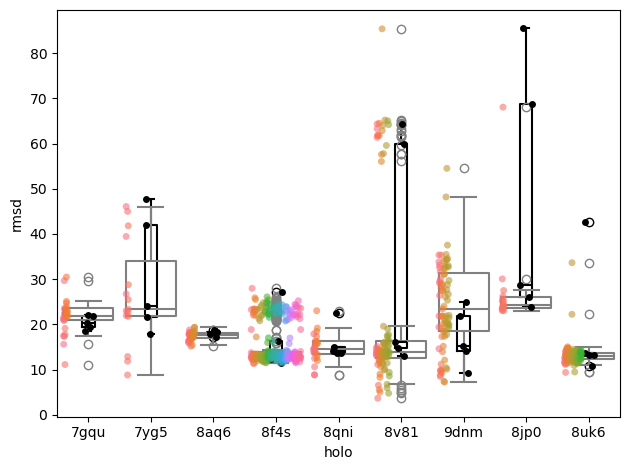

In [70]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [71]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]

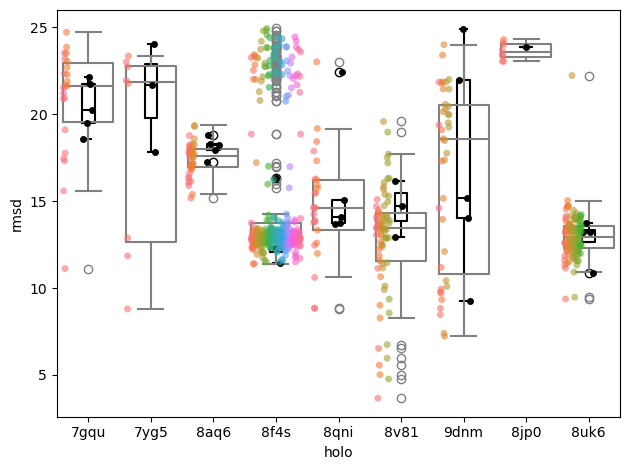

In [72]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

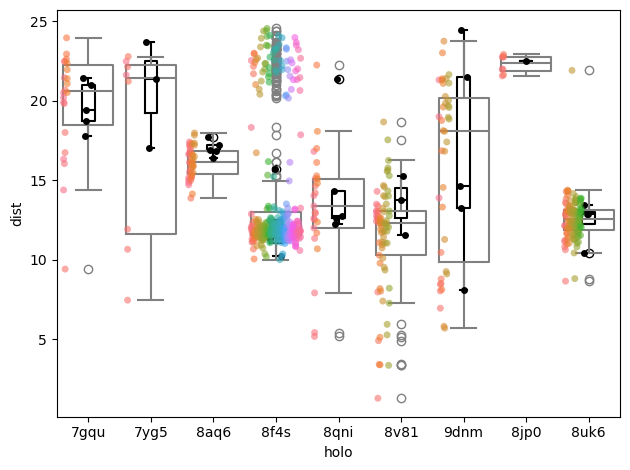

In [73]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Gnina

In [24]:
subprocess.run(
    f"""LD_LIBRARY_PATH=/home/fnerin/miniconda3/envs/bioemu/lib conda run -n bioemu /data/fnerin/ensembles/gnina.1.3.2.cuda12.8 --help""",
    shell=True, check=True
)


Input:
  -r [ --receptor ] arg              rigid part of the receptor
  --flex arg                         flexible side chains, if any (PDBQT)
  -l [ --ligand ] arg                ligand(s)
  --flexres arg                      flexible side chains specified by comma 
                                     separated list of chain:resid
  --flexdist_ligand arg              Ligand to use for flexdist
  --flexdist arg                     set all side chains within specified 
                                     distance to flexdist_ligand to flexible
  --flex_limit arg                   Hard limit for the number of flexible 
                                     residues
  --flex_max arg                     Retain at at most the closest flex_max 
                                     flexible residues

Search space (required):
  --center_x arg                     X coordinate of the center
  --center_y arg                     Y coordinate of the center
  --center_z arg                     Z

CompletedProcess(args='LD_LIBRARY_PATH=/home/fnerin/miniconda3/envs/bioemu/lib conda run -n bioemu /data/fnerin/ensembles/gnina.1.3.2.cuda12.8 --help', returncode=0)

In [34]:
gninadir = outdir / "gnina"
gninadir.mkdir(exist_ok=True)

In [47]:
dockings = []

for holo, holod in dict(
    **overlaps, # dicts have keys 'pocket', 'site_in_pocket', 'pocket_in_site', 'site'
    **{"8uk6": dict(bioemuensresults)} # dicts have keys 'pocket', 'overlap', 'merge'
).items():
    
    holopath = gninadir / holo
    holopath.mkdir(exist_ok = True)

    obabelsdf = holopath / 'holo.sdf'
    if not obabelsdf.exists():
        subprocess.run(
            f"""/data/fnerin/ensembles/neuralplexer_env/bin/obabel -:'{seqs[holo]["smiles"]}' -O{obabelsdf} --gen3D""",
            shell=True, check=True
        )

    if holo == "8uk6":
        holod.pop("frame_0")
        refapo = "frame_0"
    else:
        refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))   
    
    base_cmd = [
        "LD_LIBRARY_PATH=/home/fnerin/miniconda3/envs/bioemu/lib conda run -n bioemu /data/fnerin/ensembles/gnina.1.3.2.cuda12.8",
        f"--ligand {obabelsdf.absolute()}",
        "--cpu 8 --seed 0 --num_modes 5"
    ]
    
    for apo in (holo, refapo, *holod.keys()):
        if holo in ["7yg5", "8v81"]:
            apocif = (outdir / f"dynamicbind/{holo}/{apo}/{apo}.cif").absolute()
        else:
            apocif = (outdir / f"diffdock-pocket/{holo}/{apo}.pdb").absolute()
        apopath = holopath / apo
        apopath.mkdir(exist_ok = True)
        
        for guide in (None, "pocket", "guide"):
            if guide is not None and holo in ["7yg5", "8v81"]: continue
            if guide is None:
                autobox_opts = {'blind': f"--autobox_ligand {apocif} --exhaustiveness 64"}
            else:
                ligsdf = (outdir / f"diffdock-pocket/{holo}/{apo}_{guide}.sdf").absolute()
                autobox_opts = {guide: f"--autobox_ligand {ligsdf}"} # --autobox_add 6
                
            for flexibility in (True, False):
                if flexibility and guide is None:
                    continue
                elif flexibility:
                    flex_opts = {'flex': f"--flexdist_ligand {ligsdf} --flexdist 6 --flex_max 20 --full_flex_output"}
                else:
                    flex_opts = {'noflex': ''}
                    
                for cnn_use in ("none", "rescore", ): # , "all", "refinement"
                    cnn_opts = {f"cnn-{cnn_use}": f"--cnn_scoring {cnn_use}"}
                    
                    for scoring in ("ad4_scoring", "default", "vinardo"): # "vina" is the same as default
                        if cnn_use == "all" and scoring != "default":
                            continue
                        else:
                            score_opts = {scoring.replace("default", "def_scoring"): f"--scoring {scoring}"}
    
                        path = apopath / (apo + "_" + "_".join((k for opt in (autobox_opts, flex_opts, cnn_opts, score_opts) for k in opt.keys())))
                        path.mkdir(exist_ok = True)
    
                        outsdf = path / 'docked.sdf'
                        if not outsdf.exists() or outsdf.stat().st_size == 0:
                            cmd = " ".join(
                                base_cmd 
                                + [f"-r {apocif}"]
                                + [f"--log {(path / 'gnina.log').absolute()} --out_flex {(path / 'flex.pdb').absolute()} --out {outsdf.absolute()}"]
                                + [v for opt in (autobox_opts, flex_opts, cnn_opts, score_opts) for v in opt.values()]
                            )
                            dockings.append({"cmd": cmd, "path": path.absolute()})
                            
                            # with open(path / "log.txt", "w") as f:
                            #     start = time.time()
                            #     subprocess.run(
                            #         cmd,
                            #         shell=True, check=True, stdout=f, stderr=f
                            #     )
                            #     h, rem = divmod(time.time() - start, 3600)
                            #     m, s = divmod(rem, 60)
                            #     f.write(f"\nTime elapsed: {int(h):02d}:{int(m):02d}:{s:05.2f}")

dockings

[]

In [45]:
len(dockings)

3

In [46]:
pd.to_pickle(dockings, "dldocking/gnina_dockings.pkl")

## Tests

In [26]:
for holo, holod in dict(
    **overlaps, # dicts have keys 'pocket', 'site_in_pocket', 'pocket_in_site', 'site'
    **{"8uk6": bioemuensresults} # dicts have keys 'pocket', 'overlap', 'merge'
).items():
    
    holopath = gninadir / holo
    holopath.mkdir(exist_ok = True)

    obabelsdf = holopath / 'holo.sdf'
    if not obabelsdf.exists():
        subprocess.run(
            f"""/data/fnerin/ensembles/neuralplexer_env/bin/obabel -:'{seqs[holo]["smiles"]}' -O{obabelsdf} --gen3D""",
            shell=True, check=True
        )

    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    base_cmd = [
        "LD_LIBRARY_PATH=/home/fnerin/miniconda3/envs/bioemu/lib conda run -n bioemu /data/fnerin/ensembles/gnina.1.3.2.cuda12.8",
        f"--ligand {obabelsdf.absolute()}",
        "--cpu 8 --seed 0 --num_modes 5"
    ]
    
    for apo in (holo, refapo, holod.keys()):
        apocif = (outdir / f"diffdock-pocket/{holo}/{apo}.pdb").absolute()
        apopath = holopath / apo
        apopath.mkdir(exist_ok = True)
        
        for guide in ("guide",):#(None, "pocket", "guide"):
            if guide is None:
                autobox_opts = {'blind': f"--autobox_ligand {apocif} --exhaustiveness 64"}
            else:
                ligsdf = (outdir / f"diffdock-pocket/{holo}/{apo}_{guide}.sdf").absolute()
                autobox_opts = {guide: f"--autobox_ligand {ligsdf}"} # --autobox_add 6
                
            for flexibility in (False,): #(True, False):
                if flexibility and guide is None:
                    continue
                elif flexibility:
                    flex_opts = {'flex': f"--flexdist_ligand {ligsdf} --flexdist 6"}
                else:
                    flex_opts = {'noflex': ''}
                    
                for cnn_use in ("rescore",): #("none", "rescore", "refinement"): # , "all"
                    cnn_opts = {f"cnn-{cnn_use}": f"--cnn_scoring {cnn_use}"}
                    
                    for scoring in ("ad4_scoring",): # ("ad4_scoring", "default", "vina", "vinardo"):
                        if cnn_use == "all" and scoring != "default":
                            continue
                        else:
                            score_opts = {scoring.replace("default", "def_scoring"): f"--scoring {scoring}"}
                            # score_opts = {f"vinardo_{scoring}": f"--scoring vinardo --flex_max {scoring}"}
    
                        path = apopath / (apo + "_" + "_".join((k for opt in (autobox_opts, flex_opts, cnn_opts, score_opts) for k in opt.keys())))
                        path.mkdir(exist_ok = True)
    
                        outsdf = path / 'docked.sdf'
                        if not outsdf.exists():
                            cmd = " ".join(
                                base_cmd 
                                + [f"-r {apocif}"]
                                + [f"--log {(path / 'gnina.log').absolute()} --out_flex {(path / 'flex.pdb').absolute()} --out {outsdf.absolute()}"]
                                + [v for opt in (autobox_opts, flex_opts, cnn_opts, score_opts) for v in opt.values()]
                            )
                            
                            with open(path / "log.txt", "w") as f:
                                start = time.time()
                                subprocess.run(
                                    cmd,
                                    shell=True, check=True, stdout=f, stderr=f
                                )
                                h, rem = divmod(time.time() - start, 3600)
                                m, s = divmod(rem, 60)
                                f.write(f"\nTime elapsed: {int(h):02d}:{int(m):02d}:{s:05.2f}")
                                
        break
    break

In [18]:
times = []


for holo, holod in dict(
    **overlaps, # dicts have keys 'pocket', 'site_in_pocket', 'pocket_in_site', 'site'
    **{"8uk6": bioemuensresults} # dicts have keys 'pocket', 'overlap', 'merge'
).items():
    
    holopath = gninadir / holo


    refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
    
    for apo in (holo, refapo, holod.keys()):
        apocif = (outdir / f"diffdock-pocket/{holo}/{apo}.pdb").absolute()
        apopath = holopath / apo
        apopath.mkdir(exist_ok = True)
        
        for guide in (None, "pocket", "guide"):
            if guide is None:
                autobox_opts = {'blind': f"--autobox_ligand {apocif} --exhaustiveness 64"}
            else:
                ligsdf = (outdir / f"diffdock-pocket/{holo}/{apo}_{guide}.sdf").absolute()
                autobox_opts = {guide: f"--autobox_ligand {ligsdf}"} # --autobox_add 6
            for flexibility in (True, False):
                if flexibility and guide is None:
                    continue
                elif flexibility:
                    flex_opts = {'flex': f"--flexdist_ligand {ligsdf} --flexdist 6"}
                else:
                    flex_opts = {'noflex': ''}
                for cnn_use in ("none", "rescore", "refinement"):
                    cnn_opts = {f"cnn-{cnn_use}": f"--cnn_scoring {cnn_use}"}
                    for scoring in ("ad4_scoring", "default", "vina", "vinardo"):
                        if cnn_use == "all" and scoring != "default":
                            continue
                        else:
                            score_opts = {scoring.replace("default", "def_scoring"): f"--scoring {scoring}"}
                            
                        path = apopath / (apo + "_" + "_".join((k for opt in (autobox_opts, flex_opts, cnn_opts, score_opts) for k in opt.keys())))
                        
                        if (path / "log.txt").exists():
                            with open(path / "log.txt", "r") as f:
                                last = f.readlines()[-1].strip()
                                times.append({
                                    "apo": apo,
                                    "guide": guide or "blind",
                                    "flex": flexibility,
                                    "cnn": cnn_use,
                                    "score": scoring,
                                    "timedelta": pd.to_timedelta(last.split(": ", 1)[1]),  # e.g. "00:00:40.84"
                                    "time": last,
                                })
                                
        break
    break

In [19]:
# pd.DataFrame(times).sort_values(["guide", "flex", "cnn", "timedelta"])

pd.DataFrame(times).drop(columns=["time", "score"]).groupby(["apo", "guide", "flex", "cnn"], as_index=False).mean().sort_values("timedelta")

,apo,guide,flex,cnn,timedelta
4,7gqu,pocket,False,none,0 days 00:00:12.360000
6,7gqu,pocket,False,rescore,0 days 00:00:15.070000
0,7gqu,blind,False,none,0 days 00:00:26.057500
2,7gqu,blind,False,rescore,0 days 00:00:27.937500
1,7gqu,blind,False,refinement,0 days 00:01:29.150000
5,7gqu,pocket,False,refinement,0 days 00:01:37.852500
9,7gqu,pocket,True,rescore,0 days 00:28:30.997500
7,7gqu,pocket,True,none,0 days 00:32:39.986666666
8,7gqu,pocket,True,refinement,0 days 00:43:47.767500
3,7gqu,guide,True,none,0 days 00:55:40.840000


In [21]:
pd.DataFrame(times).query("flex == True")

,apo,guide,flex,cnn,score,timedelta,time
12,7gqu,pocket,True,none,ad4_scoring,0 days 00:38:34.120000,Time elapsed: 00:38:34.12
13,7gqu,pocket,True,none,default,0 days 00:35:15.280000,Time elapsed: 00:35:15.28
14,7gqu,pocket,True,none,vinardo,0 days 00:24:10.560000,Time elapsed: 00:24:10.56
15,7gqu,pocket,True,rescore,ad4_scoring,0 days 00:32:44.360000,Time elapsed: 00:32:44.36
16,7gqu,pocket,True,rescore,default,0 days 00:28:27.980000,Time elapsed: 00:28:27.98
17,7gqu,pocket,True,rescore,vina,0 days 00:28:31.890000,Time elapsed: 00:28:31.89
18,7gqu,pocket,True,rescore,vinardo,0 days 00:24:19.760000,Time elapsed: 00:24:19.76
19,7gqu,pocket,True,refinement,ad4_scoring,0 days 00:39:37.910000,Time elapsed: 00:39:37.91
20,7gqu,pocket,True,refinement,default,0 days 00:45:58.650000,Time elapsed: 00:45:58.65
21,7gqu,pocket,True,refinement,vina,0 days 00:47:05.390000,Time elapsed: 00:47:05.39


<Axes: xlabel='flex', ylabel='time'>

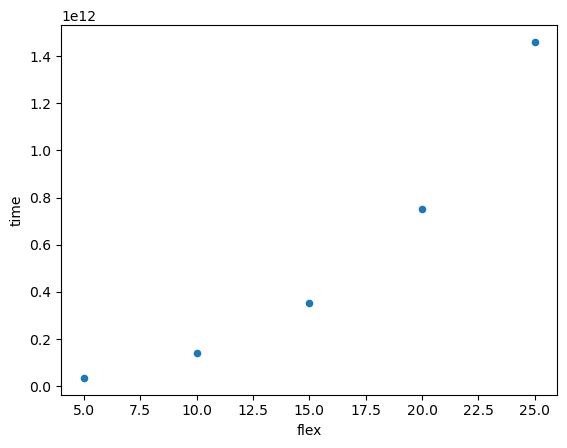

In [23]:
pd.DataFrame((
    {"flex": 5, "time": pd.to_timedelta("00:00:35.46")},
    {"flex": 10, "time": pd.to_timedelta("00:02:21.76")},
    {"flex": 15, "time": pd.to_timedelta("00:05:51.91")},
    {"flex": 20, "time": pd.to_timedelta("00:12:32.38")},
    {"flex": 25, "time": pd.to_timedelta("00:24:19.76")},
)).plot.scatter("flex", "time")

## Results

In [48]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():

    holo_segid = extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()

    holopath = gninadir / holo
    # obabelsdf = holopath / 'holo.sdf'
    hololigf = holopath / 'holo.pdb'
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        if holo in ["7yg5", "8v81"]:
            apocif = (outdir / f"dynamicbind/{holo}/{apo}/{apo}.cif").absolute()
        else:
            apocif = (outdir / f"diffdock-pocket/{holo}/{apo}.pdb").absolute()
        apopath = holopath / apo
        
        for guide in (None, "pocket", "guide"):
            autobox_opts = "blind" if guide is None else guide
            for flexibility in (True, False):
                if flexibility and guide is None: continue
                flex_opts = "flex" if flexibility else "noflex"
                for cnn_use in ("none", "rescore"): # , "all", "refinement"
                    cnn_opts = f"cnn-{cnn_use}"
                    for scoring in ("ad4_scoring", "default", "vinardo"): # "vina"
                        score_opts = scoring.replace("default", "def_scoring")
    
                        path = apopath / (apo + "_" + "_".join((autobox_opts, flex_opts, cnn_opts, score_opts)))
                        outsdf = path / 'docked.sdf'
                        if not outsdf.exists():
                            continue

                        if not (path / f"rank5.pdb").exists() or not hololigf.exists():
                            with pymol2.PyMOL() as pymol:
                                cmd = pymol.cmd
                                cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                                cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                                if not hololigf.exists():
                                    cmd.save(hololigf, f'holo and segid {seqs[holo]["site"]["mod"].label_asym_id.item()}')
                                # if (path / f"rank5.pdb").exists(): continue
    
                                cmd.load(outsdf, "lig")
                                if flexibility:
                                    cmd.load(outsdf.with_name("flex.pdb"), "apo")
                                    cmd.align('apo', f'holo and segid {holo_segid}', )
                                    cmd.split_states("apo")
                                    cmd.matrix_copy('apo', "lig", target_state=0)
                                    cmd.split_states("lig")
                                    for i in range(1,5+1):
                                        cmd.create(f"rank_{i}", f"apo_000{i} or lig_000{i}")
                                        cmd.save(path / f"rank{i}.pdb", f"rank_{i}")
                                else:
                                    cmd.load(apocif, "apo")
                                    cmd.align('apo', f'holo and segid {holo_segid}', )
                                    cmd.matrix_copy('apo', "lig", target_state=0)
                                    cmd.split_states("lig")
                                    for i in range(1,5+1):
                                        cmd.create(f"rank_{i}", f"apo or lig_000{i}",) # f"apo or (lig and state {i})"
                                        cmd.save(path / f"rank{i}.pdb", f"rank_{i}")
                                        
                            
                        ref = mda.Universe(hololigf)
                        refatoms = mda.AtomGroup(
                            sorted(
                                ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                                key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                            )
                        )
                    
                        for i in range(1,5+1):
                            lig = mda.Universe(path / f"rank{i}.pdb")
                            ligatoms = mda.AtomGroup(
                                sorted(
                                    lig.select_atoms("resname UNK and not type H"), 
                                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                                )
                            )
                            
                            rmsds.append({
                                "holo": holo,
                                "apo": apo,
                                "sample": i,
                                "guide": autobox_opts, 
                                "flex": flex_opts, 
                                "cnn": cnn_opts, 
                                "scoring": score_opts,
                                "dist": mda.analysis.distances.distance_array(
                                    refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                                ).item(),
                                "rmsd": rdMolAlign.CalcRMS(
                                    refatoms.convert_to("RDKIT", NoImplicit=False), 
                                    ligatoms.convert_to("RDKIT", NoImplicit=False)
                                )
                                #mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
                            })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

,holo,apo,sample,guide,flex,cnn,scoring,dist,rmsd
0,7gqu,7gqu,1,blind,noflex,cnn-none,ad4_scoring,1.542102,7.915981
1,7gqu,7gqu,2,blind,noflex,cnn-none,ad4_scoring,24.429268,25.071775
2,7gqu,7gqu,3,blind,noflex,cnn-none,ad4_scoring,25.522073,26.324683
3,7gqu,7gqu,4,blind,noflex,cnn-none,ad4_scoring,0.811240,7.768356
4,7gqu,7gqu,5,blind,noflex,cnn-none,ad4_scoring,25.805151,26.387111
...,...,...,...,...,...,...,...,...,...
21085,8uk6,frame_23,1,guide,noflex,cnn-rescore,vinardo,6.137198,7.093496
21086,8uk6,frame_23,2,guide,noflex,cnn-rescore,vinardo,9.939782,10.352705
21087,8uk6,frame_23,3,guide,noflex,cnn-rescore,vinardo,5.612789,6.225321
21088,8uk6,frame_23,4,guide,noflex,cnn-rescore,vinardo,8.760280,10.993174


In [49]:
rmsds_df.sort_values("dist").iloc[:50]

,holo,apo,sample,guide,flex,cnn,scoring,dist,rmsd
2442,8f4s,8f4s,3,pocket,noflex,cnn-none,vinardo,0.053067,1.589763
2455,8f4s,8f4s,1,pocket,noflex,cnn-rescore,vinardo,0.053067,1.589763
17448,8uk6,8uk6,4,guide,flex,cnn-rescore,ad4_scoring,0.106949,1.211087
12962,8qni,8qni,3,guide,flex,cnn-none,ad4_scoring,0.134361,6.824894
17361,8uk6,8uk6,2,blind,noflex,cnn-rescore,def_scoring,0.142007,7.388488
17346,8uk6,8uk6,2,blind,noflex,cnn-none,def_scoring,0.142007,7.388488
17431,8uk6,8uk6,2,guide,flex,cnn-none,ad4_scoring,0.156252,1.389389
17411,8uk6,8uk6,2,pocket,noflex,cnn-none,vinardo,0.161774,0.327438
17426,8uk6,8uk6,2,pocket,noflex,cnn-rescore,vinardo,0.161774,0.327438
17407,8uk6,8uk6,3,pocket,noflex,cnn-none,def_scoring,0.174383,0.471534


In [50]:
rmsds_df.sort_values("rmsd").iloc[-50:]

,holo,apo,sample,guide,flex,cnn,scoring,dist,rmsd
13897,8v81,7svr,3,blind,noflex,cnn-none,def_scoring,67.074561,67.397205
13771,8v81,8v81,2,blind,noflex,cnn-none,ad4_scoring,67.243208,67.450338
14193,8v81,7sv7,4,blind,noflex,cnn-none,ad4_scoring,67.291674,67.469953
14287,8v81,9dw9,3,blind,noflex,cnn-none,def_scoring,67.309799,67.484603
13868,8v81,9dw8,4,blind,noflex,cnn-none,def_scoring,67.307402,67.507306
14281,8v81,9dw9,2,blind,noflex,cnn-none,ad4_scoring,67.281585,67.520161
14192,8v81,7sv7,3,blind,noflex,cnn-none,ad4_scoring,67.455664,67.593577
13928,8v81,8gls,4,blind,noflex,cnn-none,def_scoring,67.241575,67.603565
14228,8v81,7svd,4,blind,noflex,cnn-none,def_scoring,67.544597,67.719735
13862,8v81,9dw8,3,blind,noflex,cnn-none,ad4_scoring,67.478919,67.728071


In [51]:
rmsds_df.to_pickle("dldocking/gnina_rmsds.pkl")

In [28]:
import pygwalker as pyg

<Axes: ylabel='Frequency'>

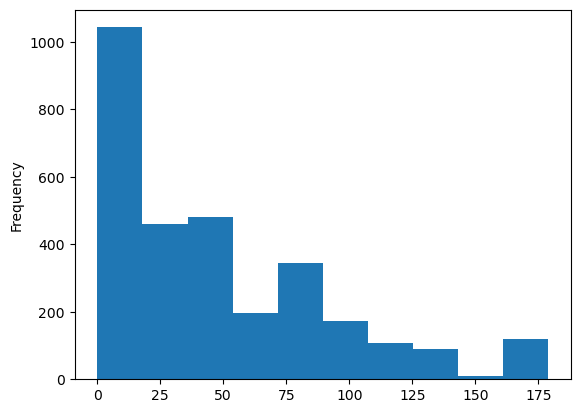

In [27]:
rmsds_df["dist"].plot.hist()

In [62]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,sample,dist,rmsd
651,8jp0,8jp0,2,85.224793,85.463613
505,8v81,8eio,1,85.308987,85.388554
650,8jp0,8jp0,1,68.528105,68.851891
665,8jp0,8sgt,1,67.795221,68.063321
510,8v81,8v7z,1,64.924164,65.200710
521,8v81,9dw7,2,64.389429,65.031655
545,8v81,7sv7,1,64.175397,64.481963
476,8v81,8v81,2,63.866791,64.371827
530,8v81,6msm,1,64.011924,64.348341
494,8v81,9dw8,5,63.976329,64.184438


In [63]:
rmsds_df.sort_values("rmsd").iloc[:40]

,holo,apo,sample,dist,rmsd
487,8v81,6o1v,3,1.286419,3.655860
493,8v81,9dw8,4,3.354759,4.762244
551,8v81,7svd,2,3.386904,5.008271
548,8v81,7sv7,4,3.410139,5.560061
526,8v81,9dw5,2,5.268428,5.960103
569,8v81,6o2p,5,4.906716,6.520110
525,8v81,9dw5,1,5.931623,6.742772
636,9dnm,8i0q,2,5.690508,7.222666
640,9dnm,8i0n,1,5.809630,7.397677
554,8v81,7svd,5,5.118013,8.280218


In [58]:
from ipymolstar import PDBeMolstar

In [68]:
holo = "8jp0"
apo = "8jp0"
i = 2
PDBeMolstar(
        custom_data = {
                'data': open(f"dldocking/dynamicbind/{holo}/{apo}/result_{i}.pdb", "r").read(),
                'format': 'pdb',
                'binary': False,
            },
        sequence_panel = True,
        assembly_id=''
    )

PDBeMolstar(bg_color='#F7F7F7', custom_data={'data': 'CRYST1    1.000    1.000    1.000  90.00  90.00  90.00 P…

#### Plot

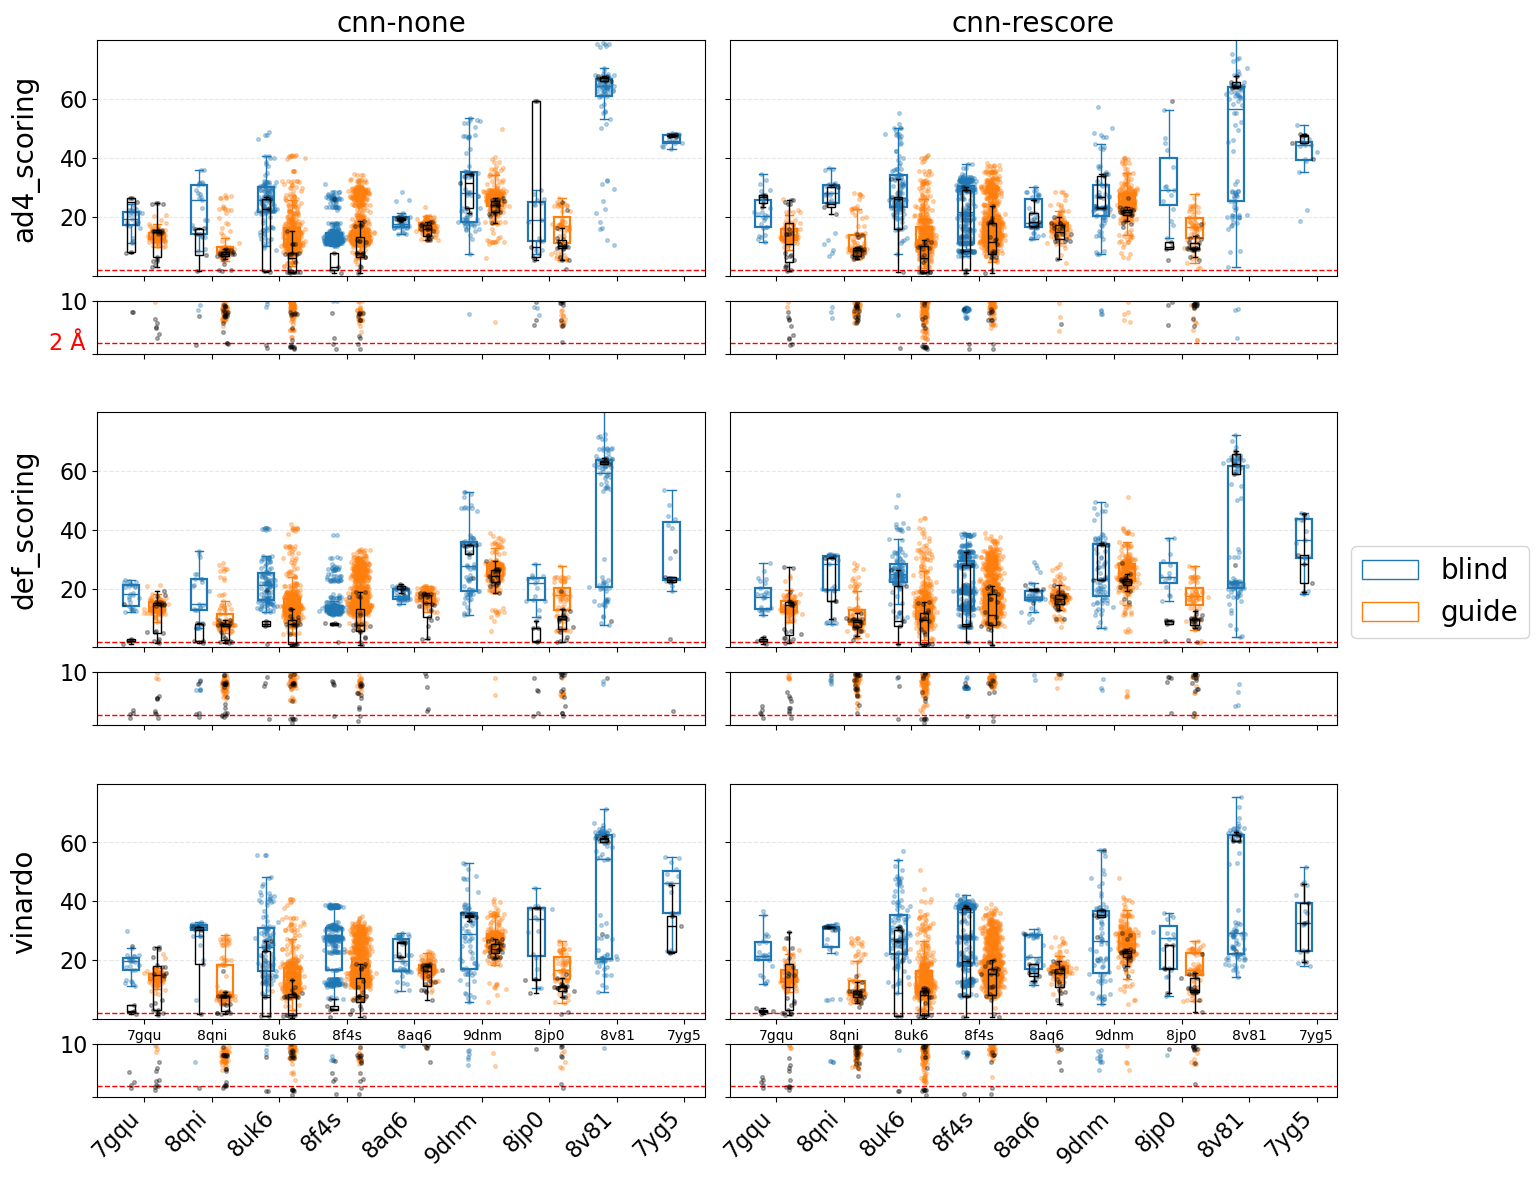

In [60]:
# Configurable plotting cell
# Define which dataframe columns will control facets, colors and splits.
# Set these to any categorical columns present in `results`.
row_var = 'scoring'    # facet rows (set to None to disable)
col_var = 'cnn'     # facet cols (set to None to disable)
split_var = 'guide'    # defines how many boxplots per holo (one box per split level)
hue_var = 'guide'  # used for coloring the box outlines (mapped to split levels)

# Always-used columns
x_col = 'holo'
y_col = 'rmsd'

# Define expected/possible values for these columns. If the dataframe already contains
# values we'll prefer those; otherwise these lists act as the canonical universe
# (we prepare to handle combinations that might not exist yet in the dataframe).
# You may edit these lists if you already know the full set of possible values.
possible_guide_vals = None
possible_flex_vals = None
possible_cnn_vals = None
possible_scoring_vals = None

# Holo order and ignored columns
holo_order = ['7gqu','8qni','8uk6','8f4s','8aq6','9dnm','8jp0','8v81','7yg5']
ignore_cols = ['sample','dist']

# Plot settings
figsize_per_plot = (8, 4)   # width, height per main subplot (small subplot will be ~1/4 height)
main_box_width = 0.24       # width of the main (colored) box
black_box_width = 0.12      # width of the black overlay box (narrower)
point_jitter = 0.06        # jitter scale relative to 1.0 x spacing
point_size = 7
palette_name = 'tab10'

# Font scaling: tweak this multiplier to scale all plot fonts
font_scale = 2
base_title_fs = 10 * font_scale
base_tick_fs = 8 * font_scale
base_label_fs = 10 * font_scale

# Tweaks for small (0-10) subplot
small_jitter_scale = point_jitter * 0.35
small_point_size = 7 #max(2, int(point_size * 0.8))
small_alpha = 0.3
small_offset_scale = 1 #0.5  # reduce horizontal separation for small plot

# --- Implementation (generic, robust) ---
# Import plotting/math libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch

# Make a working copy of the data; normalize 'guide' labels for consistency
df = rmsds_df.copy().assign(guide = rmsds_df["guide"].map({"guide": "guide", "pocket": "guide", "blind": "blind"}))

# Provide defaults for possible lists using dataframe if available
if possible_guide_vals is None:
    possible_guide_vals = sorted(df['guide'].dropna().unique().tolist()) if 'guide' in df.columns else []
if possible_flex_vals is None:
    possible_flex_vals = sorted(df['flex'].dropna().unique().tolist()) if 'flex' in df.columns else []
if possible_cnn_vals is None:
    possible_cnn_vals = sorted(df['cnn'].dropna().unique().tolist()) if 'cnn' in df.columns else []
if possible_scoring_vals is None:
    possible_scoring_vals = sorted(df['scoring'].dropna().unique().tolist()) if 'scoring' in df.columns else []

# Choose which levels to use for split variable (the groups shown per holo)
if split_var is not None and split_var in df.columns:
    split_levels = sorted(df[split_var].dropna().unique().tolist())
else:
    split_levels = []

# If hue_var is provided but not present, fall back to split_var for coloring
if hue_var is None or hue_var not in df.columns:
    hue_for_palette = split_var
else:
    hue_for_palette = hue_var

# Build a color palette mapping so every relevant level has a color
palette_levels = split_levels if split_levels else (sorted(df[hue_for_palette].dropna().unique().tolist()) if hue_for_palette in df.columns else [])
palette = sns.color_palette(palette_name, max(3, len(palette_levels)))
color_map = {lvl: palette[i % len(palette)] for i, lvl in enumerate(palette_levels)}

# Prepare facet levels (rows and columns)
row_levels = [None]
col_levels = [None]
if row_var and row_var in df.columns:
    row_levels = sorted(df[row_var].dropna().unique().tolist())
if col_var and col_var in df.columns:
    col_levels = sorted(df[col_var].dropna().unique().tolist())

nrows = max(1, len(row_levels))
ncols = max(1, len(col_levels))

# Create figure and GridSpec: each facet row gets a main plot and a small plot below it
fig_w = ncols * figsize_per_plot[0]
# increase height to accommodate small subplot
fig_h = nrows * (figsize_per_plot[1] * 1.15)
fig = plt.figure(figsize=(fig_w, fig_h))
# We'll allocate 3 GridSpec rows per facet-row: main, small, spacer
# This lets us keep the main and small tightly stacked while adding a spacer between groups
from matplotlib.gridspec import GridSpec
n_gs_rows = nrows * 3
# height ratios: [main, small, spacer] per group
height_ratios = []
for _ in range(nrows):
    height_ratios.extend([4, 0.9, 0.15])
gs = GridSpec(n_gs_rows, ncols, figure=fig, height_ratios=height_ratios)

# Keep references to axes so we can address them later
axes_main = [[None for _ in range(ncols)] for _ in range(nrows)]
axes_small = [[None for _ in range(ncols)] for _ in range(nrows)]

# Create the axes for every grid location (main + small stacked)
for r_idx in range(nrows):
    for c_idx in range(ncols):
        ax_main = fig.add_subplot(gs[r_idx * 3 + 0, c_idx])
        ax_small = fig.add_subplot(gs[r_idx * 3 + 1, c_idx], sharex=ax_main)
        axes_main[r_idx][c_idx] = ax_main
        axes_small[r_idx][c_idx] = ax_small

# For each facet: draw main and small plots
for r_idx, r_val in enumerate(row_levels):
    for c_idx, c_val in enumerate(col_levels):
        ax = axes_main[r_idx][c_idx]
        ax_small = axes_small[r_idx][c_idx]

        # Filter dataframe to this facet
        sub_df = df.copy()
        if row_var and row_var in sub_df.columns:
            sub_df = sub_df[sub_df[row_var] == r_val]
        if col_var and col_var in sub_df.columns:
            sub_df = sub_df[sub_df[col_var] == c_val]

        # positions: one integer per holo; compute offsets when multiple split levels exist
        base_xs = np.arange(len(holo_order))
        n_splits = max(1, len(split_levels))
        offsets = None
        if n_splits == 1:
            offsets = [0.0]
        else:
            # center the groups around the base x; spacing depends on main_box_width
            span = main_box_width * 1.6
            offsets = np.linspace(-span/2, span/2, n_splits)

        # First, plot jittered points (behind boxes) on main axes
        for si, split_val in enumerate(split_levels if split_levels else [None]):
            xs_plot = []
            ys_plot = []
            for i, holo in enumerate(holo_order):
                filt = sub_df[(sub_df[x_col] == holo) & (sub_df["apo"] != sub_df["holo"])]
                if split_val is not None:
                    filt = filt[filt[split_var] == split_val]
                vals = filt[y_col].dropna().values
                if vals.size == 0:
                    continue
                xpos = i + offsets[si]
                # jitter per point
                jitter = np.random.normal(scale=point_jitter, size=vals.size)
                xs_plot.extend(xpos + jitter)
                ys_plot.extend(vals)
            # plot points behind boxes
            color = color_map.get(split_val, (0.5, 0.5, 0.5))
            if len(xs_plot) > 0:
                ax.scatter(xs_plot, ys_plot, color=color, alpha=0.3, s=point_size, zorder=1)

        # Overlay black points for rows where apo == holo (main plot). Plot after colored points so they appear on top
        if 'apo' in sub_df.columns:
            for si, split_val in enumerate(split_levels if split_levels else [None]):
                black_xs = []
                black_ys = []
                for i, holo in enumerate(holo_order):
                    filt = sub_df[sub_df[x_col] == holo]
                    if split_val is not None:
                        filt = filt[filt[split_var] == split_val]
                    # rows where apo equals holo (row-wise)
                    filt_black = filt[filt['apo'] == filt[x_col]] if not filt.empty else filt
                    vals_black = filt_black[y_col].dropna().values
                    if vals_black.size == 0:
                        continue
                    xpos = i + offsets[si]
                    jitter = np.random.normal(scale=point_jitter, size=vals_black.size)
                    black_xs.extend(xpos + jitter)
                    black_ys.extend(vals_black)
                if len(black_xs) > 0:
                    # plot black overlay points on top
                    ax.scatter(black_xs, black_ys, color='black', alpha=0.3, s=point_size, zorder=6)

        # Then, plot the main boxes (transparent fill, colored edges)
        for si, split_val in enumerate(split_levels if split_levels else [None]):
            bpositions = []
            bdata = []
            for i, holo in enumerate(holo_order):
                filt = sub_df[(sub_df[x_col] == holo) & (sub_df["apo"] != sub_df["holo"])]
                if split_val is not None:
                    filt = filt[filt[split_var] == split_val]
                vals = filt[y_col].dropna().values
                if vals.size == 0:
                    # still reserve a position so xticks align, but skip plotting
                    bpositions.append(i + offsets[si])
                    bdata.append([])
                else:
                    bpositions.append(i + offsets[si])
                    bdata.append(vals)
            # matplotlib boxplot can receive a list of datasets; we plot only where data exists
            # we'll iterate per position to easily control widths and styling
            for pos, data_vals in zip(bpositions, bdata):
                if len(data_vals) == 0:
                    continue
                col = color_map.get(split_val, (0.4, 0.4, 0.4))
                bp = ax.boxplot(data_vals, positions=[pos], widths=main_box_width, patch_artist=True,
                                boxprops=dict(facecolor='none', color=col, linewidth=1.6),
                                whiskerprops=dict(color=col), capprops=dict(color=col), medianprops=dict(color=col),
                                flierprops=dict(marker='o', markersize=3, alpha=0.0))

                # Now black overlay box for rows where holo == apo (if column exists)
                if 'apo' in sub_df.columns:
                    # find data where holo equals apo in the filtered group
                    holo_value = None
                    i_approx = int(round(pos))
                    if 0 <= i_approx < len(holo_order):
                        holo_value = holo_order[i_approx]
                    if holo_value is not None:
                        filt_black = sub_df[(sub_df[x_col] == holo_value) & (sub_df['apo'] == sub_df[x_col])]
                        if split_val is not None:
                            filt_black = filt_black[filt_black[split_var] == split_val]
                        black_vals = filt_black[y_col].dropna().values
                        if black_vals.size > 0:
                            # draw narrower black box on top to highlight apo==holo
                            ax.boxplot(black_vals, positions=[pos], widths=black_box_width, patch_artist=True,
                                       boxprops=dict(facecolor='none', color='black', linewidth=1.0),
                                       whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black'),
                                       flierprops=dict(marker='o', markersize=2, alpha=0.0), zorder=10)

        # Axis formatting for main axes
        ax.set_xticks(np.arange(len(holo_order)))
        # Hide xticklabels on main axes; they'll appear on the bottom-most small plots
        ax.set_xticklabels([''] * len(holo_order))

        # Y axis limits/ticks: same for all main plots
        main_yticks = [0, 20, 40, 60]
        ax.set_ylim(0, 80)
        ax.set_yticks(main_yticks)
        # show labels only on first column, hide labels for the 0 tick
        if c_idx == 0:
            ax.set_yticklabels(['', '20', '40', '60'])
        else:
            ax.set_yticklabels([''] * len(main_yticks))

        # set tick label sizes for main axes
        ax.tick_params(axis='y', labelsize=base_tick_fs)

        # Add a horizontal dashed red line at y=2 on every main subplot
        ax.axhline(2, color='red', linestyle='--', linewidth=1.0, zorder=0)
        # Do not add y-axis title (remove all y-axis titles)
        ax.set_ylabel('')

        # If top row, use column-level titles above columns
        if r_idx == 0 and col_var and col_var in df.columns:
            ax.set_title(str(c_val), fontsize=base_title_fs)
        else:
            # otherwise no per-plot title
            ax.set_title('')

        # Add a left-side row label for the entire row on the first column axes
        if c_idx == 0 and row_var and row_var in df.columns:
            # place row name to the left of the main axis (moved closer)
            ax.text(-0.12, 0.5, str(r_val), transform=ax.transAxes, rotation=90, va='center', ha='center', fontsize=base_label_fs)

        ax.grid(axis='y', linestyle='--', alpha=0.3)

        # --- Small lower subplot: show rmsd in 0-10 range, points only (no boxplots) ---
        # For each split level draw the same scatter but only points within 0-10
        small_offsets = np.array(offsets) * small_offset_scale
        for si, split_val in enumerate(split_levels if split_levels else [None]):
            xs_plot = []
            ys_plot = []
            for i, holo in enumerate(holo_order):
                filt = sub_df[(sub_df[x_col] == holo) & (sub_df["apo"] != sub_df["holo"])]
                if split_val is not None:
                    filt = filt[filt[split_var] == split_val]
                vals = filt[y_col].dropna().values
                if vals.size == 0:
                    continue
                # keep only values in 0-10 range for the small subplot
                mask = (vals >= 0) & (vals <= 10)
                if not mask.any():
                    continue
                vals_small = vals[mask]
                xpos = i + small_offsets[si]
                jitter = np.random.normal(scale=small_jitter_scale, size=vals_small.size)
                xs_plot.extend(xpos + jitter)
                ys_plot.extend(vals_small)
            color = color_map.get(split_val, (0.5, 0.5, 0.5))
            if len(xs_plot) > 0:
                ax_small.scatter(xs_plot, ys_plot, color=color, alpha=small_alpha, s=small_point_size, zorder=1)

        # Overlay black points for apo==holo in the small plot (on top of colored points)
        if 'apo' in sub_df.columns:
            for si, split_val in enumerate(split_levels if split_levels else [None]):
                black_xs = []
                black_ys = []
                for i, holo in enumerate(holo_order):
                    filt = sub_df[sub_df[x_col] == holo]
                    if split_val is not None:
                        filt = filt[filt[split_var] == split_val]
                    if filt.empty:
                        continue
                    filt_black = filt[filt['apo'] == filt[x_col]]
                    vals_black = filt_black[y_col].dropna().values
                    if vals_black.size == 0:
                        continue
                    xpos = i + small_offsets[si]
                    jitter = np.random.normal(scale=small_jitter_scale, size=vals_black.size)
                    black_xs.extend(xpos + jitter)
                    black_ys.extend(vals_black)
                if len(black_xs) > 0:
                    ax_small.scatter(black_xs, black_ys, color='black', alpha=small_alpha, s=small_point_size, zorder=6)

        # Format small axes: show x tick labels only on the last row of small plots
        ax_small.set_xticks(np.arange(len(holo_order)))
        if r_idx == nrows - 1:
            ax_small.set_xticklabels(holo_order, rotation=45, ha='right')
            # set x tick label size for visible xticklabels
            ax_small.tick_params(axis='x', labelsize=base_tick_fs)
        else:
            ax_small.set_xticklabels([''] * len(holo_order))

        # small subplot y-range 0-10 and show ticks at 0 (no label) and 10 (label)
        ax_small.set_ylim(0, 10)
        small_yticks = [0, 10]
        ax_small.set_yticks(small_yticks)
        if c_idx == 0:
            ax_small.set_yticklabels(['', '10'])
        else:
            ax_small.set_yticklabels([''] * len(small_yticks))
        # set small y tick label size
        ax_small.tick_params(axis='y', labelsize=base_tick_fs)

        # Add red dashed line at y=2 on small plot as well
        ax_small.axhline(2, color='red', linestyle='--', linewidth=1.0, zorder=0)
        # On the very first subplot's small axis, add the left-outside label '2 Å' in red (closer to the plot)
        if r_idx == 0 and c_idx == 0:
            ax_small.text(-0.02, 2, '2 Å', transform=ax_small.get_yaxis_transform(), color='red', va='center', ha='right', fontsize=base_tick_fs)

        # Remove y-axis labels for small axes too (we're using row label text instead)
        ax_small.set_ylabel('')

# Build legend for split levels and place it centered to the right of the grid
legend_handles = []
for lvl in palette_levels:
    legend_handles.append(Patch(edgecolor=color_map.get(lvl, (0.5,0.5,0.5)), facecolor='none', label=str(lvl)))
if legend_handles:
    # use scaled font for the legend
    fig.legend(handles=legend_handles, bbox_to_anchor=(0.9, 0.5), loc='center left', prop={'size': base_label_fs})

# Final layout: keep small spacing between main and small plots, but spacer rows separate groups
plt.subplots_adjust(hspace=0.25, wspace=0.04, top=0.90)
fig.savefig(outdir / "gnina.svg", transparent=True, bbox_inches='tight')
plt.show()

#### Old plots

In [69]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

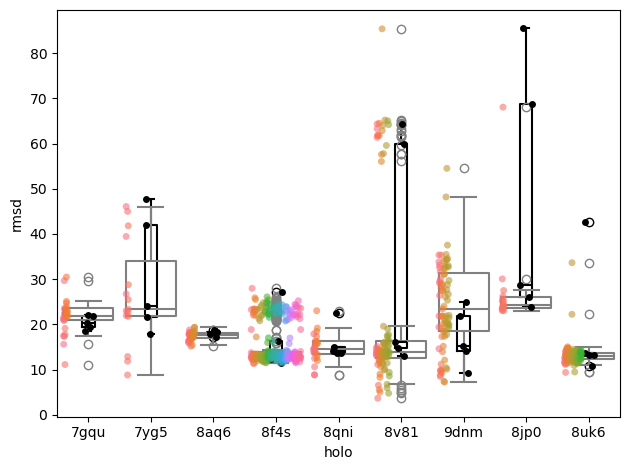

In [70]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [71]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]

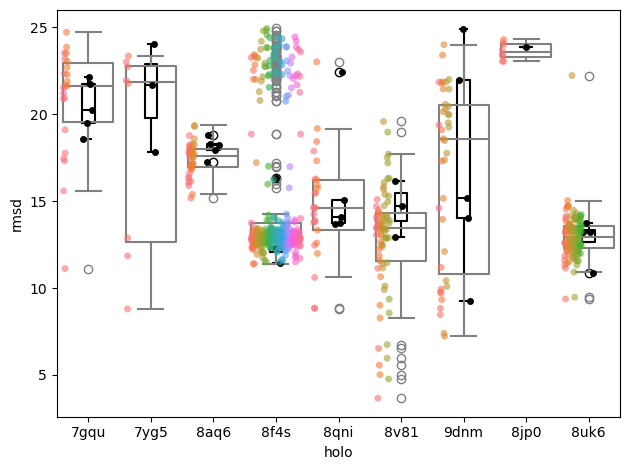

In [72]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

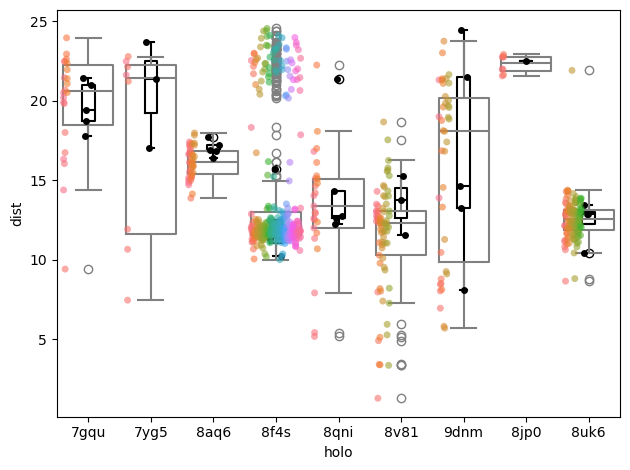

In [73]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Glide - blind

In [38]:
glide_rmsds = {}

In [39]:
glidedir = Path("glide")

## Results

In [40]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    # if holo in ("7yg5", "8v81"):
    #     continue

    holo_segid = extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()
    
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        if not (glidedir / holo / apo).exists(): ###########################################
            print((glidedir / holo / apo), "doesn't exist")
            continue

        with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
            with pymol2.PyMOL() as pymol:
                cmd = pymol.cmd
                cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                
                if apo != holo:
                    if holo == "8uk6":
                        apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                    else:
                        apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                    cmd.load(apof, "apo")
                    cmd.align(f'holo and segid {holo_segid}', 'apo')
                               
                cmd.select("ligand", f'holo and segid {extra_holos_sites[holo][0]["mod"].label_asym_id.unique().item()}')
                cmd.save(f.name, "ligand")

                #############################################################################################
                if not (glidedir / holo / apo / "rank1.pdb").exists():
                    for i in range(1,5+1):
                        try:
                            cmd.load(next((glidedir / holo / apo).glob(f"{apo}_rank{i}_*.pdb")), f"docked_{i}")
                        except StopIteration: continue
                        cmd.align(f"docked_{i}", 'apo' if apo != holo else f"holo and segid {holo_segid}")
                        cmd.save(glidedir / holo / apo / f"rank{i}.pdb", f"docked_{i} and hetatm and resn UNK")
                        cmd.save(glidedir / holo / apo / f"result_{i}.pdb", (f"ligand or docked_{i}") + (" or apo" if apo != holo else " or holo"))
                
            ref = mda.Universe(f.name)
            refatoms = mda.AtomGroup(
                sorted(
                    ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
        
        for i in range(1,5+1):
            rankf = glidedir / holo / apo / f"rank{i}.pdb"
            if not rankf.exists(): continue
            lig = mda.Universe(rankf)
            # lig.trajectory[-1]
            ligatoms = mda.AtomGroup(
                sorted(
                    lig.select_atoms("not type H"), 
                    key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                )
            )
            
            rmsds.append({
                "holo": holo,
                "apo": apo,
                "sample": i,
                "dist": mda.analysis.distances.distance_array(
                    refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                ).item(),
                "rmsd": rdMolAlign.CalcRMS(
                            refatoms.convert_to("RDKIT", NoImplicit=False), 
                            ligatoms.convert_to("RDKIT", NoImplicit=False)
                        )
                        # mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
            })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


,holo,apo,sample,dist,rmsd
0,7gqu,7gqu,1,0.461040,1.870426
1,7gqu,7gqu,2,0.761436,2.129434
2,7gqu,7gqu,3,26.023551,26.651235
3,7gqu,7gqu,4,26.253430,26.897860
4,7gqu,7gqu,5,16.108361,16.713240
...,...,...,...,...,...
762,8uk6,frame_23,1,24.604143,25.308620
763,8uk6,frame_23,2,23.731957,24.490588
764,8uk6,frame_23,3,34.236999,34.767001
765,8uk6,frame_23,4,34.063322,34.530176


In [41]:
glide_rmsds["blind"] = rmsds_df

In [79]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,sample,dist,rmsd
476,8v81,8gls,5,79.531686,79.820558
638,8jp0,8sgt,2,78.141176,78.434070
449,8v81,8v81,3,73.291574,73.611530
507,8v81,9dw4,1,73.111990,73.601932
624,8jp0,8jp0,3,72.433814,72.830566
634,8jp0,9iv8,3,71.813784,72.251971
463,8v81,9dw8,2,71.773969,72.036580
498,8v81,9dw5,2,69.797820,70.245362
497,8v81,9dw5,1,69.404286,69.982890
630,8jp0,8sgj,4,69.078960,69.360366


In [80]:
rmsds_df.sort_values("rmsd").iloc[:40]

,holo,apo,sample,dist,rmsd
447,8v81,8v81,1,0.605805,1.289343
515,8v81,8eig,4,1.777222,2.719780
67,8f4s,8f4s,1,0.611569,3.450173
448,8v81,8v81,2,2.298715,3.875833
418,8qni,8qni,2,0.303463,4.148316
421,8qni,8qni,5,0.493642,4.208541
419,8qni,8qni,3,0.348631,4.225215
420,8qni,8qni,4,0.496670,4.254582
439,8qni,8vw4,3,0.528451,4.290910
417,8qni,8qni,1,0.454064,4.380179


In [58]:
from ipymolstar import PDBeMolstar

#### Plots

In [82]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

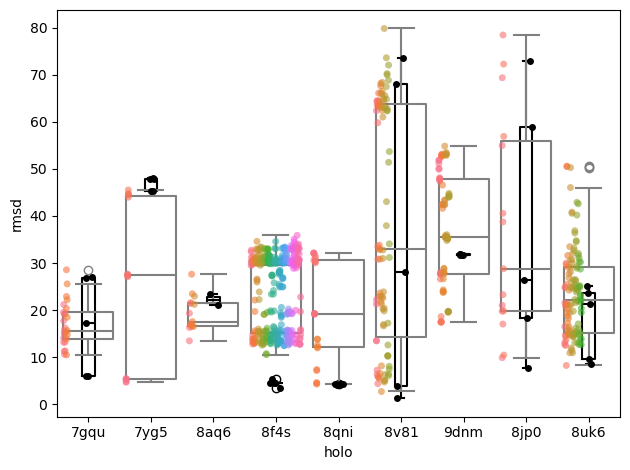

In [83]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [84]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 35]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 35]

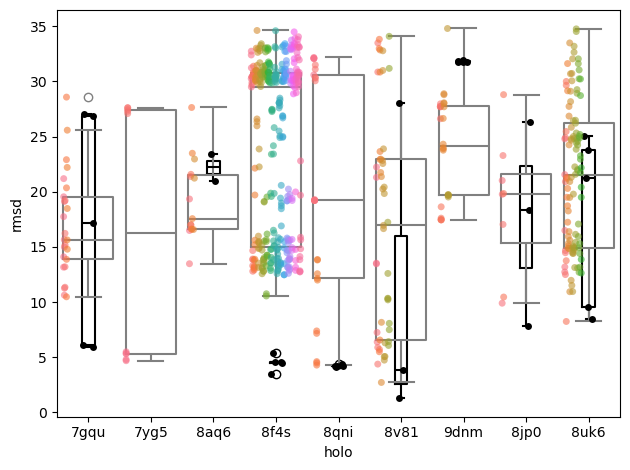

In [85]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

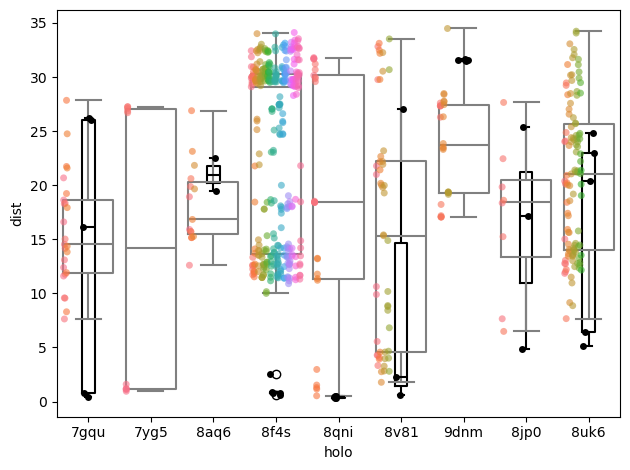

In [86]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Glide - guided

In [17]:
dockings = {}

for holo, holod in dict(
    **overlaps,
    **{"8uk6": None}
).items():
    if holo in ("7yg5", "8v81"): # There are no good guide residues or pockets for these
        continue

    guideres = guide_res[holo]["topres"] # label_seq_id will prob be wrong for 8uk6 apos

    files = {
        holo: {
            "ciff": f"../training_data/7.Extra_set/cifs/{holo}.cif",
            "pfile": f"../training_data/7.Extra_set/pockets/{holo}/{holo}_out/{holo}_out.cif",
            "pocket": pd.DataFrame(origholos["results"][holo]).T.sort_values("prob", ascending=False).iloc[0].name.replace('pocket', '')
        }
    }
    
    if holo == "8uk6":
        files.update({
            frame: {
                "ciff": bioemuensdir / f"predictions/{frame}/{frame}.cif",
                "pfile": bioemuensdir / f"predictions/{frame}/{frame}/{frame}_out/{frame}_out.cif",
                "pocket": framed['pocket'].replace('pocket', '')
            }
            for frame, framed in bioemuensresults.items()
        })
    else:
        refapo = next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        files[refapo] = {
            "ciff": f"../training_data/8.Apos/Extra_set/cifs/{refapo}.cif",
            "pfile": f"../training_data/8.Apos/Extra_set/pockets/{refapo}/{refapo}_out/{refapo}_out.cif",
            "pocket": pd.DataFrame( origapos["results"][refapo] ).T.sort_values("prob", ascending=False).iloc[0].name.replace('pocket', '')
        }
        files.update({
            apo: {
                "ciff": f"pdb_ensemble/predictions/{apo}/{apo}.cif",
                "pfile": f"pdb_ensemble/predictions/{apo}/{apo}/{apo}_out/{apo}_out.cif",
                "pocket": apod['pocket'].replace('pocket', '')
            }
            for apo, apod in holod.items()
        })

    
    for apo, apod in files.items():
        ciff = apod["ciff"]
        cifres = Cif(apo, ciff).residues
        
        with pymol2.PyMOL() as pymol:
            cmd = pymol.cmd
            cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"            
            cmd.load(apod["pfile"], "pockets")
            for label, sel in [
                ("pocket", f"resn STP and resi {apod['pocket']}"), 
                (
                    "guide",
                     " or ".join(
                        f"{res['label_asym_id']}/{res['auth_asym_id']}/{res['auth_comp_id']}`{res['auth_seq_id']}{res['pdbx_PDB_ins_code'].replace('?', '')}/*"
                        for i, res in cifres.merge(
                            guideres if apo != "8uk6" else (guideres.astype(int) + 233).astype(str)
                        ).iterrows()
                    )
                )
            ]:
                cmd.pseudoatom(f"{label}_cog", selection=sel)
                files[apo][f"{label}_cog"] = cmd.get_model(f"{label}_cog").atom[0].coord
                
    dockings[holo] = files

dockings

{'7gqu': {'7gqu': {'ciff': '../training_data/7.Extra_set/cifs/7gqu.cif',
   'pfile': '../training_data/7.Extra_set/pockets/7gqu/7gqu_out/7gqu_out.cif',
   'pocket': '1',
   'pocket_cog': [6.964241027832031, 26.42584991455078, 16.23856544494629],
   'guide_cog': [11.84740161895752, 24.034400939941406, 21.308034896850586]},
  '6yhr': {'ciff': '../training_data/8.Apos/Extra_set/cifs/6yhr.cif',
   'pfile': '../training_data/8.Apos/Extra_set/pockets/6yhr/6yhr_out/6yhr_out.cif',
   'pocket': '1',
   'pocket_cog': [-17.198780059814453,
    -19.426149368286133,
    32.649749755859375],
   'guide_cog': [-9.501700401306152, -14.058333396911621, 39.8582649230957]},
  '7gqt': {'ciff': 'pdb_ensemble/predictions/7gqt/7gqt.cif',
   'pfile': 'pdb_ensemble/predictions/7gqt/7gqt/7gqt_out/7gqt_out.cif',
   'pocket': '5',
   'pocket_cog': [11.266744613647461, -2.0004360675811768, -5.426126956939697],
   'guide_cog': [6.413934230804443, -3.6677331924438477, -8.020732879638672]},
  '8yle': {'ciff': 'pdb_ens

In [18]:
pd.to_pickle(dockings, "glide/glide-guided_dockings.pkl")

## Results

In [42]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    if holo in ("7yg5", "8v81"):
        continue

    holo_segid = extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()
    
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        for guide in ("pocket", "guide"):
            path = glidedir / f"{holo}_{guide}" / apo
            if not path.exists() or not any(path.iterdir()): ###########################################
                print(path, " doesn't exist")
                continue
    
            with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
                with pymol2.PyMOL() as pymol:
                    cmd = pymol.cmd
                    cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                    cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                    
                    if apo != holo:
                        if holo == "8uk6":
                            apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                        else:
                            apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                        cmd.load(apof, "apo")
                        cmd.align(f'holo and segid {holo_segid}', 'apo')
                                   
                    cmd.select("ligand", f'holo and segid {extra_holos_sites[holo][0]["mod"].label_asym_id.unique().item()}')
                    cmd.save(f.name, "ligand")
    
                    #############################################################################################
                    if not (glidedir / f"{holo}_{guide}" / apo / "rank1.pdb").exists():
                        for i in range(1,5+1):
                            try:
                                cmd.load(next((glidedir / f"{holo}_{guide}" / apo).glob(f"{apo}_rank{i}.pdb")), f"docked_{i}")
                            except StopIteration: continue
                            cmd.align(f"docked_{i}", 'apo' if apo != holo else f"holo and segid {holo_segid}")
                            cmd.save(glidedir / f"{holo}_{guide}" / apo / f"rank{i}.pdb", f"docked_{i} and hetatm and resn UNK")
                            cmd.save(glidedir / f"{holo}_{guide}" / apo / f"result_{i}.pdb", (f"ligand or docked_{i}") + (" or apo" if apo != holo else " or holo"))
                    
                ref = mda.Universe(f.name)
                refatoms = mda.AtomGroup(
                    sorted(
                        ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
            
            for i in range(1,5+1):
                rankf = glidedir / f"{holo}_{guide}" / apo / f"rank{i}.pdb"
                if not rankf.exists(): continue
                lig = mda.Universe(rankf)
                # lig.trajectory[-1]
                ligatoms = mda.AtomGroup(
                    sorted(
                        lig.select_atoms("not type H"), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
                
                rmsds.append({
                    "holo": holo,
                    "apo": apo,
                    "guide": guide,
                    "sample": i,
                    "dist": mda.analysis.distances.distance_array(
                        refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                    ).item(),
                    "rmsd": rdMolAlign.CalcRMS(
                                refatoms.convert_to("RDKIT", NoImplicit=False), 
                                ligatoms.convert_to("RDKIT", NoImplicit=False)
                            )
                            # mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
                })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

glide/8aq6_pocket/7vsx  doesn't exist
glide/8qni_guide/8qni  doesn't exist
glide/8qni_guide/3pfv  doesn't exist
glide/8qni_pocket/3zni  doesn't exist
glide/8qni_guide/3zni  doesn't exist
glide/9dnm_pocket/9dnm  doesn't exist
glide/9dnm_pocket/4jqi  doesn't exist


/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


glide/9dnm_guide/9dng  doesn't exist
glide/9dnm_guide/8hst  doesn't exist
glide/9dnm_guide/8ja3  doesn't exist
glide/9dnm_guide/6kl7  doesn't exist
glide/9dnm_guide/8j8z  doesn't exist
glide/9dnm_guide/9bt8  doesn't exist
glide/9dnm_guide/8hsv  doesn't exist
glide/9dnm_pocket/8gp3  doesn't exist
glide/9dnm_guide/8gp3  doesn't exist
glide/9dnm_pocket/8i0q  doesn't exist
glide/9dnm_guide/8i0q  doesn't exist
glide/9dnm_guide/8i0n  doesn't exist
glide/9dnm_guide/8go8  doesn't exist


,holo,apo,guide,sample,dist,rmsd
0,7gqu,7gqu,pocket,1,14.044232,14.928469
1,7gqu,7gqu,pocket,2,13.985812,14.858799
2,7gqu,7gqu,pocket,3,13.930492,14.757763
3,7gqu,7gqu,pocket,4,14.116679,15.077565
4,7gqu,7gqu,pocket,5,14.063410,15.082828
...,...,...,...,...,...,...
1234,8uk6,frame_23,guide,1,12.003518,13.874554
1235,8uk6,frame_23,guide,2,11.579469,11.821747
1236,8uk6,frame_23,guide,3,11.546680,11.774472
1237,8uk6,frame_23,guide,4,11.400998,11.658292


In [43]:
glide_rmsds["guided"] = rmsds_df

In [30]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,guide,sample,dist,rmsd
931,9dnm,9cx3,pocket,5,49.787784,49.965667
928,9dnm,9cx3,pocket,2,49.778526,49.954642
927,9dnm,9cx3,pocket,1,49.639447,49.815524
1180,8uk6,frame_18,pocket,2,41.438594,41.812247
1181,8uk6,frame_18,pocket,3,40.597347,40.873040
1179,8uk6,frame_18,pocket,1,40.325245,40.623770
1182,8uk6,frame_18,pocket,4,40.186955,40.617817
1183,8uk6,frame_18,pocket,5,39.925622,40.396182
930,9dnm,9cx3,pocket,4,37.276172,37.556558
929,9dnm,9cx3,pocket,3,37.123287,37.402551


In [31]:
rmsds_df.sort_values("rmsd").iloc[:40]

,holo,apo,guide,sample,dist,rmsd
992,8uk6,8uk6,pocket,4,0.539547,2.674885
990,8uk6,8uk6,pocket,2,0.147509,2.843774
989,8uk6,8uk6,pocket,1,0.111127,2.855710
991,8uk6,8uk6,pocket,3,0.469654,2.908286
136,8f4s,8f4s,pocket,3,0.825407,3.548236
135,8f4s,8f4s,pocket,2,0.736342,3.755004
134,8f4s,8f4s,pocket,1,0.895092,3.789916
830,8qni,8qni,pocket,1,0.500984,4.087924
832,8qni,8qni,pocket,3,0.473484,4.229809
831,8qni,8qni,pocket,2,0.320436,4.370575


In [32]:
from ipymolstar import PDBeMolstar

#### Plots

In [33]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

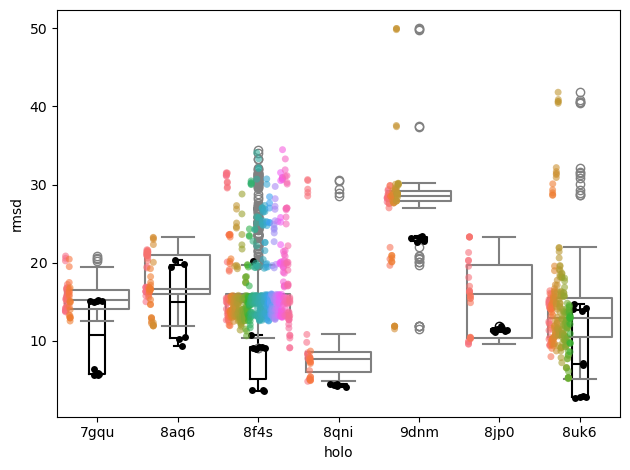

In [34]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]

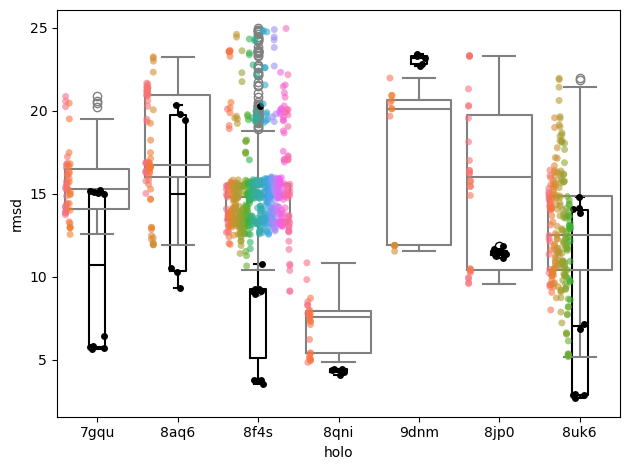

In [36]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

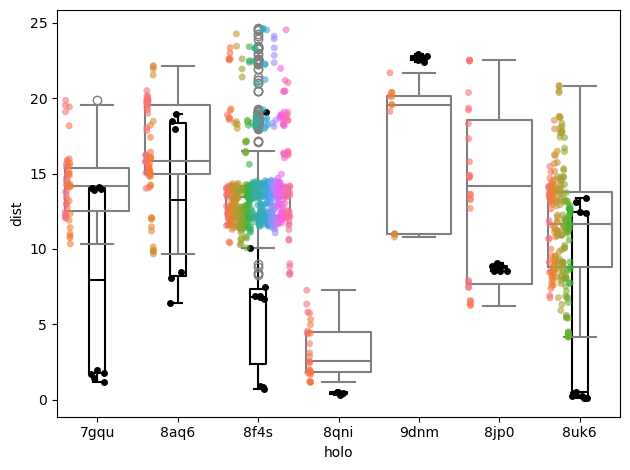

In [37]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [38]:
df_base_bu  = df_base
df_other_bu = df_other
df_base = df_base_bu.query("guide == 'pocket'")
df_other = df_other_bu.query("guide == 'pocket'")

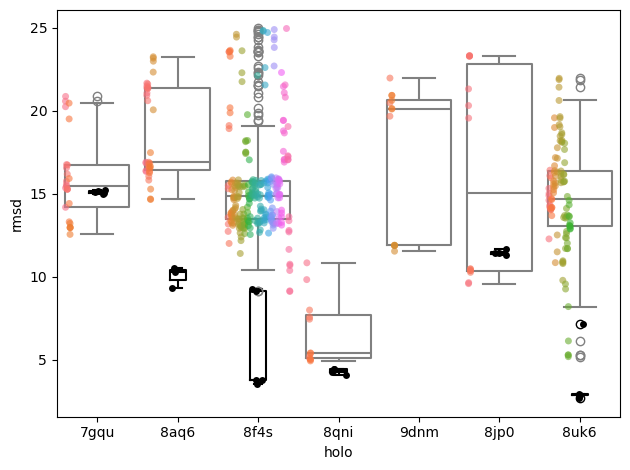

In [39]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [40]:
df_base = df_base_bu.query("guide == 'guide'")
df_other = df_other_bu.query("guide == 'guide'")

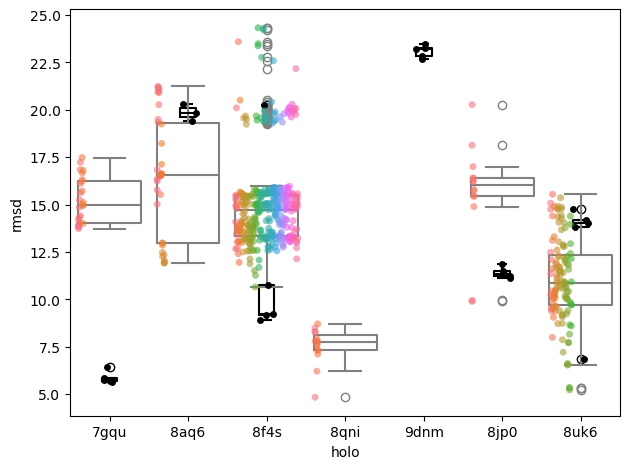

In [41]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Glide - guided, bigger

## Results

In [16]:
glidedir = Path("glide_bigger")

In [17]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    # if holo in ("7yg5", "8v81"):
    #     continue

    holo_segid = extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()
    
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        for guide in ("pocket", "guide"):
            path = glidedir / f"{holo}_{guide}" / apo
            if not path.exists() or not any(path.iterdir()): ###########################################
                print(path, "doesn't exist")
                continue
    
            with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
                with pymol2.PyMOL() as pymol:
                    cmd = pymol.cmd
                    cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                    cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                    
                    if apo != holo:
                        if holo == "8uk6":
                            apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                        else:
                            apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                        cmd.load(apof, "apo")
                        cmd.align(f'holo and segid {holo_segid}', 'apo')
                                   
                    cmd.select("ligand", f'holo and resn {seqs[holo]["ccd"]}')
                    cmd.save(f.name, "ligand")
    
                    #############################################################################################
                    for i in range(1,5+1):
                        try:
                            cmd.load(next((glidedir / f"{holo}_{guide}" / apo).glob(f"{apo}_rank{i}.pdb")), f"docked_{i}")
                        except StopIteration: continue
                        cmd.align(f"docked_{i}", 'apo' if apo != holo else f"holo and segid {holo_segid}")
                        cmd.save(glidedir / f"{holo}_{guide}" / apo / f"rank{i}.pdb", f"docked_{i} and hetatm and resn UNK")
                        cmd.save(glidedir / f"{holo}_{guide}" / apo / f"result_{i}.pdb", (f"ligand or docked_{i}") + (" or apo" if apo != holo else " or holo"))
                    
                ref = mda.Universe(f.name)
                refatoms = mda.AtomGroup(
                    sorted(
                        ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
            
            for i in range(1,5+1):
                rankf = glidedir / f"{holo}_{guide}" / apo / f"rank{i}.pdb"
                if not rankf.exists(): continue
                lig = mda.Universe(rankf)
                # lig.trajectory[-1]
                ligatoms = mda.AtomGroup(
                    sorted(
                        lig.select_atoms("not type H"), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
                
                rmsds.append({
                    "holo": holo,
                    "apo": apo,
                    "guide": guide,
                    "sample": i,
                    "dist": mda.analysis.distances.distance_array(
                        refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                    ).item(),
                    "rmsd": mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
                })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

glide_bigger/7yg5_pocket/7yg5 doesn't exist
glide_bigger/7yg5_guide/7yg5 doesn't exist
glide_bigger/7yg5_pocket/7xlq doesn't exist
glide_bigger/7yg5_guide/7xlq doesn't exist
glide_bigger/7yg5_pocket/8epm doesn't exist
glide_bigger/7yg5_guide/8epm doesn't exist
glide_bigger/7yg5_pocket/8epl doesn't exist
glide_bigger/7yg5_guide/8epl doesn't exist
glide_bigger/8v81_pocket/8v81 doesn't exist
glide_bigger/8v81_guide/8v81 doesn't exist
glide_bigger/8v81_pocket/5uak doesn't exist
glide_bigger/8v81_guide/5uak doesn't exist
glide_bigger/8v81_pocket/6o1v doesn't exist
glide_bigger/8v81_guide/6o1v doesn't exist
glide_bigger/8v81_pocket/9dw8 doesn't exist
glide_bigger/8v81_guide/9dw8 doesn't exist
glide_bigger/8v81_pocket/7svr doesn't exist
glide_bigger/8v81_guide/7svr doesn't exist
glide_bigger/8v81_pocket/8gls doesn't exist
glide_bigger/8v81_guide/8gls doesn't exist
glide_bigger/8v81_pocket/8eio doesn't exist
glide_bigger/8v81_guide/8eio doesn't exist
glide_bigger/8v81_pocket/8v7z doesn't exist

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


glide_bigger/9dnm_guide/8j8z doesn't exist
glide_bigger/9dnm_pocket/8gp3 doesn't exist


,holo,apo,guide,sample,dist,rmsd
0,7gqu,7gqu,pocket,1,13.860415,15.147910
1,7gqu,7gqu,pocket,2,13.965122,15.034147
2,7gqu,7gqu,pocket,3,14.159057,15.537191
3,7gqu,7gqu,pocket,4,14.156850,15.487627
4,7gqu,7gqu,pocket,5,14.089668,15.126257
...,...,...,...,...,...,...
1327,8uk6,frame_23,guide,1,12.339953,13.381463
1328,8uk6,frame_23,guide,2,14.111752,15.093218
1329,8uk6,frame_23,guide,3,13.492516,14.174155
1330,8uk6,frame_23,guide,4,13.598961,14.207572


In [22]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,guide,sample,dist,rmsd
988,9dnm,9cx3,pocket,1,51.653195,51.825198
991,9dnm,9cx3,pocket,4,49.622827,49.798134
989,9dnm,9cx3,pocket,2,49.491840,49.666156
1274,8uk6,frame_18,pocket,3,41.420902,41.782874
1275,8uk6,frame_18,pocket,4,41.286622,41.666522
1276,8uk6,frame_18,pocket,5,40.464428,40.759079
1273,8uk6,frame_18,pocket,2,40.256082,40.692712
1272,8uk6,frame_18,pocket,1,40.281815,40.578667
936,9dnm,6u1n,pocket,1,39.196174,39.481049
1024,9dnm,8i0n,pocket,2,38.175667,38.433364


In [23]:
rmsds_df.sort_values("rmsd").iloc[:40]

,holo,apo,guide,sample,dist,rmsd
1084,8uk6,8uk6,pocket,3,0.537245,2.674299
1091,8uk6,8uk6,guide,5,0.583895,2.792473
1083,8uk6,8uk6,pocket,2,0.173871,2.842971
1087,8uk6,8uk6,guide,1,0.249276,2.857331
1082,8uk6,8uk6,pocket,1,0.101068,2.858132
1088,8uk6,8uk6,guide,2,0.190227,2.862439
1089,8uk6,8uk6,guide,3,0.389368,3.124554
1085,8uk6,8uk6,pocket,4,0.323580,3.165790
1090,8uk6,8uk6,guide,4,0.287387,3.176485
1086,8uk6,8uk6,pocket,5,0.791699,3.176869


In [32]:
from ipymolstar import PDBeMolstar

In [24]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

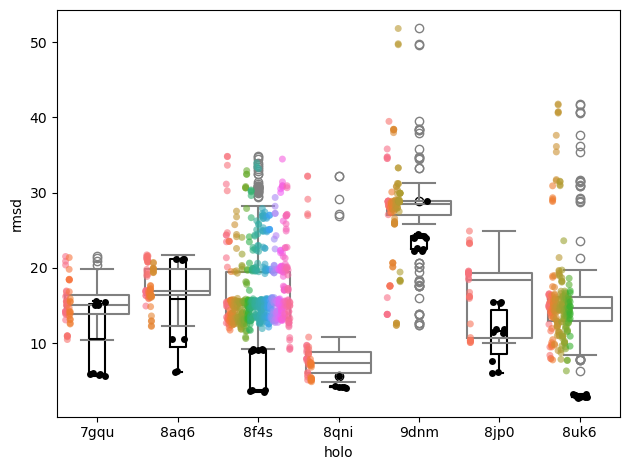

In [25]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [26]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]

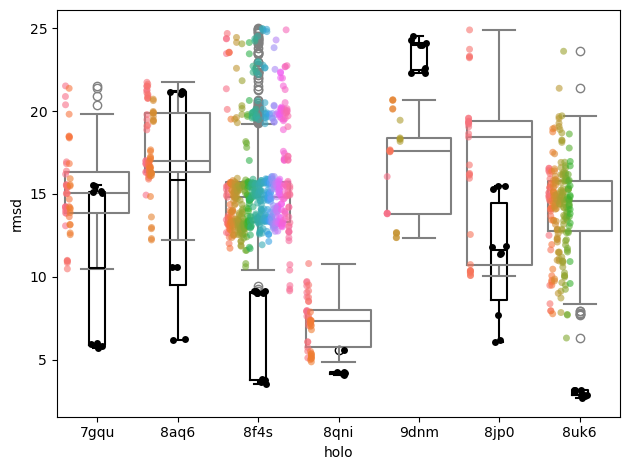

In [27]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

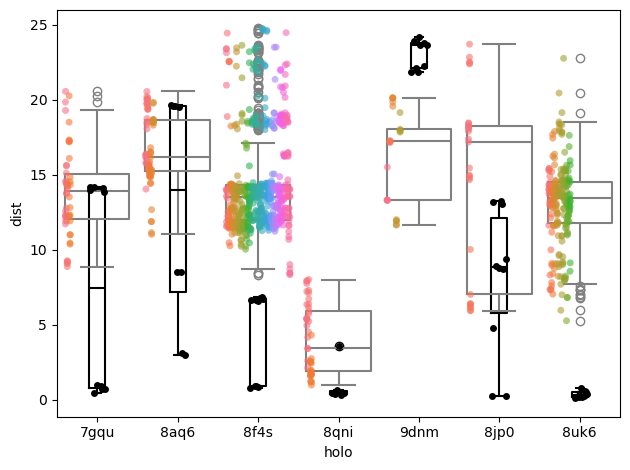

In [28]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [29]:
df_base_bu  = df_base
df_other_bu = df_other
df_base = df_base_bu.query("guide == 'pocket'")
df_other = df_other_bu.query("guide == 'pocket'")

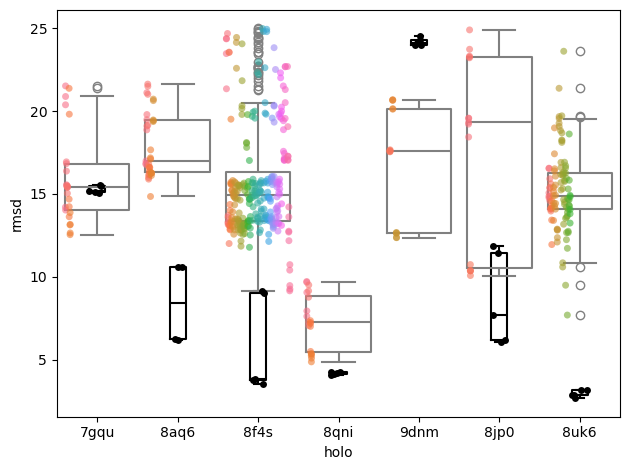

In [30]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [31]:
df_base = df_base_bu.query("guide == 'guide'")
df_other = df_other_bu.query("guide == 'guide'")

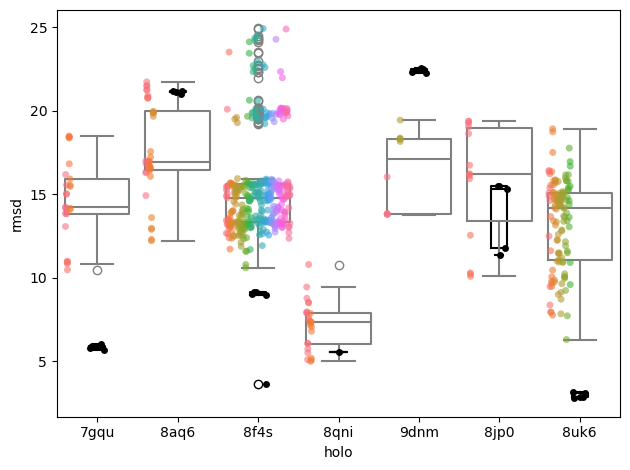

In [32]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Glide - IFD

## Results

In [44]:
glidedir = Path("glide_ifd")

In [45]:
rmsds = []

for holo, holod in dict(
    **overlaps,
    **{"8uk6": {f: None for f in bioemuensresults.keys() if f != "frame_0"}}
).items():
    if holo in ("7yg5", "8v81"):
        continue

    holo_segid = extra_holos_sites[holo][0]["site"].label_asym_id.unique().item()
    
    refapo = "frame_0" if holo == "8uk6" else next(apo for apo in apos[holo] if apo in os.listdir("../training_data/8.Apos/Extra_set/features"))
        
    for apo in [holo, refapo] + list(holod.keys()):
        for guide in ("pocket", "guide"):
            path = glidedir / f"{holo}_{guide}" / apo
            if not path.exists() or not any(path.iterdir()): ###########################################
                print(path, "doesn't exist")
                continue
    
            with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+") as f:
                with pymol2.PyMOL() as pymol:
                    cmd = pymol.cmd
                    cmd.feedback("disable", "executive", "details") # to silence "ExecutiveLoad-Detail: Detected mmCIF"
                    cmd.load(f"../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz", "holo")
                    
                    if apo != holo:
                        if holo == "8uk6":
                            apof = bioemuensdir / f"predictions/{apo}/{apo}.cif"
                        else:
                            apof = f"pdb_ensemble/predictions/{apo}/{apo}.cif" if apo != refapo else f"../training_data/8.Apos/Extra_set/cifs/{apo}.cif"
                        cmd.load(apof, "apo")
                        cmd.align(f'holo and segid {holo_segid}', 'apo')
                                   
                    cmd.select("ligand", f'holo and segid {extra_holos_sites[holo][0]["mod"].label_asym_id.unique().item()}')
                    cmd.save(f.name, "ligand")
    
                    #############################################################################################
                    if not (glidedir / f"{holo}_{guide}" / apo / "rank1.pdb").exists():
                        for i in range(1,5+1):
                            try:
                                cmd.load(next((glidedir / f"{holo}_{guide}" / apo).glob(f"{apo}_rank{i}.pdb")), f"docked_{i}")
                            except StopIteration: continue
                            cmd.align(f"docked_{i}", 'apo' if apo != holo else f"holo and segid {holo_segid}")
                            cmd.save(glidedir / f"{holo}_{guide}" / apo / f"rank{i}.pdb", f"docked_{i} and hetatm and resn UNK")
                            cmd.save(glidedir / f"{holo}_{guide}" / apo / f"result_{i}.pdb", (f"ligand or docked_{i}") + (" or apo" if apo != holo else " or holo"))
                    
                ref = mda.Universe(f.name)
                refatoms = mda.AtomGroup(
                    sorted(
                        ref.select_atoms("altLoc A" if holo=="7gqu" else 'not type H'), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
            
            for i in range(1,5+1):
                rankf = glidedir / f"{holo}_{guide}" / apo / f"rank{i}.pdb"
                if not rankf.exists(): continue
                lig = mda.Universe(rankf)
                # lig.trajectory[-1]
                ligatoms = mda.AtomGroup(
                    sorted(
                        lig.select_atoms("not type H"), 
                        key=lambda a: (''.join(filter(str.isalpha, a.name)), int(''.join(filter(str.isdigit, a.name)) or 0))
                    )
                )
                
                rmsds.append({
                    "holo": holo,
                    "apo": apo,
                    "guide": guide,
                    "sample": i,
                    "dist": mda.analysis.distances.distance_array(
                        refatoms.center_of_geometry(), ligatoms.center_of_geometry()
                    ).item(),
                    "rmsd": rdMolAlign.CalcRMS(
                                refatoms.convert_to("RDKIT", NoImplicit=False), 
                                ligatoms.convert_to("RDKIT", NoImplicit=False)
                            )
                            # mda.analysis.rms.rmsd(refatoms.positions, ligatoms.positions, center=False, superposition=False)
                })
        
rmsds_df = pd.DataFrame(rmsds)
rmsds_df

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:453: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn("1 A^3 CRYST1 record,"


,holo,apo,guide,sample,dist,rmsd
0,7gqu,7gqu,pocket,1,14.108184,15.361055
1,7gqu,7gqu,pocket,2,14.217952,15.420150
2,7gqu,7gqu,pocket,3,13.512661,14.693824
3,7gqu,7gqu,pocket,4,14.182146,15.377492
4,7gqu,7gqu,pocket,5,14.200436,15.458831
...,...,...,...,...,...,...
1355,8uk6,frame_23,guide,1,9.830143,10.930983
1356,8uk6,frame_23,guide,2,9.634826,10.701953
1357,8uk6,frame_23,guide,3,10.331935,12.021251
1358,8uk6,frame_23,guide,4,10.046594,11.227548


In [46]:
glide_rmsds["ifd"] = rmsds_df

In [36]:
glide_rmsds

{'blind':      holo       apo  sample       dist       rmsd
 0    7gqu      7gqu       1   0.461040   5.971505
 1    7gqu      7gqu       2   0.761436   6.101642
 2    7gqu      7gqu       3  26.023551  26.842320
 3    7gqu      7gqu       4  26.253430  27.031477
 4    7gqu      7gqu       5  16.108361  17.176457
 ..    ...       ...     ...        ...        ...
 762  8uk6  frame_23       1  24.604143  25.320029
 763  8uk6  frame_23       2  23.731957  24.435118
 764  8uk6  frame_23       3  34.236999  34.750754
 765  8uk6  frame_23       4  34.063322  34.511857
 766  8uk6  frame_23       5  23.068490  23.845161
 
 [767 rows x 5 columns],
 'guided':       holo       apo   guide  sample       dist       rmsd
 0     7gqu      7gqu  pocket       1  14.044232  15.088371
 1     7gqu      7gqu  pocket       2  13.985812  15.055237
 2     7gqu      7gqu  pocket       3  13.930492  14.987100
 3     7gqu      7gqu  pocket       4  14.116679  15.170910
 4     7gqu      7gqu  pocket       5  14.

In [47]:
pd.concat((
    namedf.assign(soft = name)
    for name, namedf in glide_rmsds.items()
)).to_pickle("glide/glide_rmsds.pkl")

In [28]:
rmsds_df.sort_values("rmsd", ascending=False).iloc[:40]

,holo,apo,guide,sample,dist,rmsd
1012,9dnm,9cx3,pocket,3,41.882349,42.128640
1301,8uk6,frame_18,pocket,2,41.314211,41.710439
1010,9dnm,9cx3,pocket,1,41.456590,41.703933
1013,9dnm,9cx3,pocket,4,41.452129,41.700309
1303,8uk6,frame_18,pocket,4,40.889488,41.303069
1302,8uk6,frame_18,pocket,3,40.436560,40.907830
1014,9dnm,9cx3,pocket,5,40.501079,40.706828
1011,9dnm,9cx3,pocket,2,40.177079,40.435747
1300,8uk6,frame_18,pocket,1,39.307871,39.727972
1304,8uk6,frame_18,pocket,5,38.915104,39.329565


In [29]:
rmsds_df.sort_values("rmsd").iloc[:40]

,holo,apo,guide,sample,dist,rmsd
1115,8uk6,8uk6,guide,1,0.154921,2.848036
1112,8uk6,8uk6,pocket,3,0.136248,2.855437
1114,8uk6,8uk6,pocket,5,0.314591,2.862964
1111,8uk6,8uk6,pocket,2,0.397823,2.873411
1113,8uk6,8uk6,pocket,4,0.473556,2.882071
1116,8uk6,8uk6,guide,2,0.489141,2.890314
1110,8uk6,8uk6,pocket,1,0.469504,2.893267
1118,8uk6,8uk6,guide,4,0.410713,2.896761
1117,8uk6,8uk6,guide,3,0.246219,2.899707
1119,8uk6,8uk6,guide,5,0.413716,2.912189


In [32]:
from ipymolstar import PDBeMolstar

In [30]:
rmsds_df2 = (
    rmsds_df
    .assign(
        apo_idx = rmsds_df.groupby("holo")["apo"].transform(lambda s: pd.factorize(s, sort=True)[0] + 1).astype("category"),
        is_holo = rmsds_df["apo"].eq(rmsds_df["holo"])
    )#.loc[lambda x: x["rmsd"] < 200]
)

df_base  = rmsds_df2[rmsds_df2["is_holo"]]
df_other = rmsds_df2[~rmsds_df2["is_holo"]]
all_holos = rmsds_df2["holo"].unique()

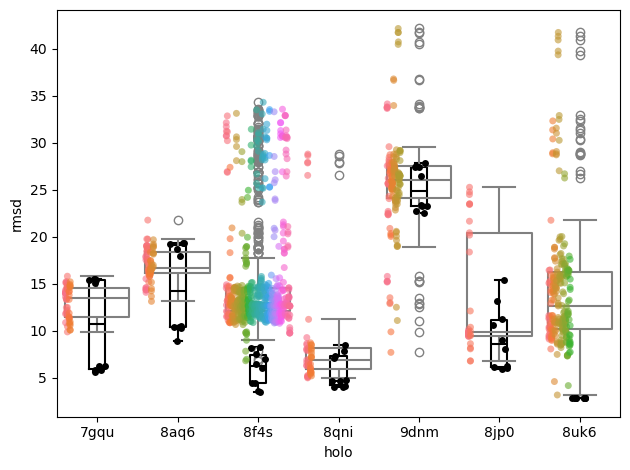

In [31]:
# sns.boxplot(
#     data=rmsds_df2, x="holo", y="rmsd", fill=False, dodge=True,
#     hue="is_holo", palette={True: "black", False: "gray"}
# )
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos #hue="is_holo", palette={True: "black", False: "gray"}
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

# sns.boxplot(data=df_other, x="holo", y="rmsd", fill=False, color="gray")
# sns.boxplot(data=rmsds_df2, x="holo", y="rmsd", hue="apo", fill=False)

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
df_base  = rmsds_df2[rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]
df_other = rmsds_df2[~rmsds_df2["is_holo"]].loc[lambda x: x["rmsd"] < 25]

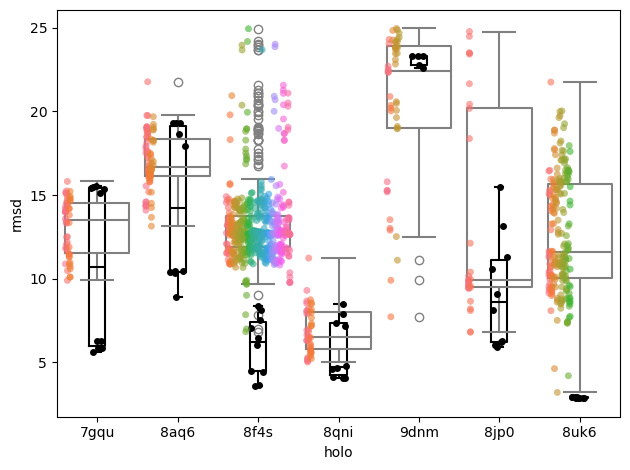

In [33]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

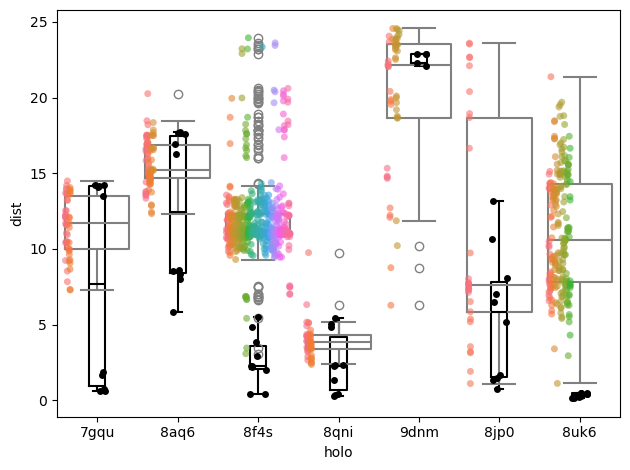

In [34]:
sns.boxplot(
    data=df_base, x="holo", y="dist", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="dist", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="dist", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="dist", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
df_base_bu  = df_base
df_other_bu = df_other
df_base = df_base_bu.query("guide == 'pocket'")
df_other = df_other_bu.query("guide == 'pocket'")

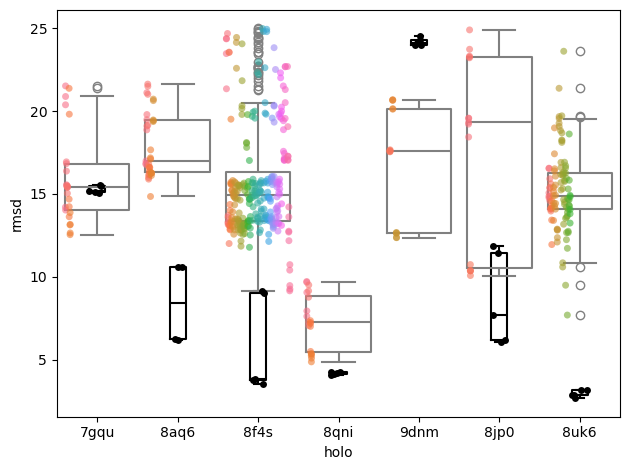

In [30]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [31]:
df_base = df_base_bu.query("guide == 'guide'")
df_other = df_other_bu.query("guide == 'guide'")

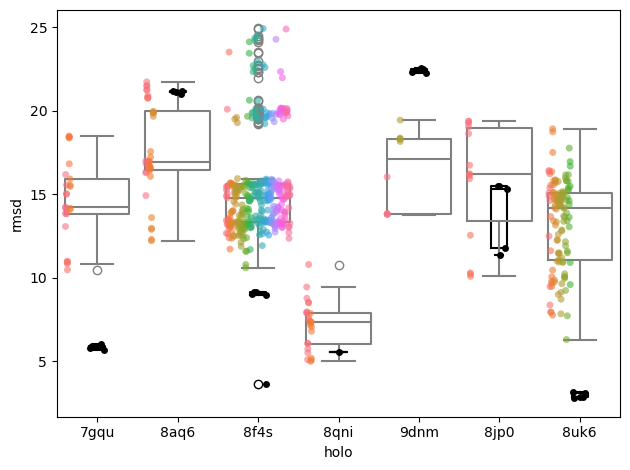

In [32]:
sns.boxplot(
    data=df_base, x="holo", y="rmsd", fill=False, dodge=True,
    color="black", width=0.2, order=all_holos
)
sns.boxplot(
    data=df_other, x="holo", y="rmsd", fill=False, dodge=True,
    color="gray", order=all_holos
)
sns.stripplot(
    data=df_base, x="holo", y="rmsd", color="black",
    dodge=True,  jitter=True, marker="o", order=all_holos # alpha=0.6,
)
sns.stripplot(
    data=df_other, x="holo", y="rmsd", hue="apo_idx",
    dodge=True, alpha=0.6, jitter=True, marker="o", order=all_holos
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()